# Phase 1 · Task 1A · Step 1 — Reference-fork plot comparison

**Reference fork:** [`github.com/kevindavisross/symbulate`](https://github.com/kevindavisross/symbulate) (cloned locally — the setup cell prints the exact path, branch, and commit).

**Purpose.** Visually inspect how each *existing* plot type in the reference fork renders for every data configuration listed in **Task 1A**, so the team can fill in the default-plot lookup table. This notebook only **observes** current behavior. It does **not** implement `classify_data`, the lookup table, or any Phase 2+ code, and it does **not** modify the reference fork or your working fork.

**How to read this notebook**

* Each example builds its simulation **once** (with a fixed seed) and reuses that result for every plot type.
* Every `.plot()` call is wrapped by a helper that labels the outcome:
  * **SUCCESS** — rendered with visible content.
  * **UNSUPPORTED** — either raised a *guarded* error (e.g. `mosaic` on non-discrete data) **or** produced an **empty** plot (the plot type has no dispatch branch for this data configuration).
  * **BROKEN** — raised an *unexpected* exception.
* One failing plot never stops the notebook (Section-5 helper catches exceptions).
* Warnings that reveal plotting / compatibility / deprecation problems are surfaced under each plot; only routine repetition is de-emphasised.
* Titles on every plot carry the distribution/model, the sample size `n`, and the requested plot type.


## 0. Environment &amp; reference-fork import setup

Your workspace has `symbulate` installed as an **editable package** (a setuptools `_EditableFinder` on `sys.meta_path` maps the name `symbulate` to your *working* fork). The cell below overrides that for this kernel session only — it removes the editable finder, drops the workspace path, and puts the reference-fork clone first on `sys.path`, then **verifies** that `symbulate` really imported from the clone (and raises a clear error otherwise). Nothing on disk is changed; your fork and its install are untouched.

In [1]:
import os, sys

# --- Locate the kevindavisross reference-fork clone (NOT your working fork) ---
_CANDIDATES = [
    os.environ.get('SYMBULATE_REF_FORK', ''),
    '/Users/roland/Documents/calpoly-symbulate/reference_forks/kevindavisross_symbulate',
    os.path.join(os.getcwd(), 'reference_forks', 'kevindavisross_symbulate'),
    os.path.abspath(os.path.join(os.getcwd(), '..', 'reference_forks', 'kevindavisross_symbulate')),
]
REF = None
for _c in _CANDIDATES:
    if _c and os.path.isfile(os.path.join(_c, 'symbulate', '__init__.py')):
        REF = os.path.abspath(_c)
        break
if REF is None:
    raise FileNotFoundError(
        'Could not find the kevindavisross reference-fork clone. Set the environment variable '
        'SYMBULATE_REF_FORK to its path. Tried: ' + repr(_CANDIDATES))
print('Reference fork location :', REF)

WORKSPACE_FORK = '/Users/roland/Documents/calpoly-symbulate'

# 1) forget any already-imported symbulate submodules
for _m in list(sys.modules):
    if _m == 'symbulate' or _m.startswith('symbulate.'):
        del sys.modules[_m]

# 2) strip the editable-install finder(s) for symbulate off sys.meta_path
def _is_symbulate_editable_finder(f):
    mod = (getattr(f, '__module__', '') or '').lower()
    return ('editable' in mod) and ('symbulate' in mod)
_removed = [f for f in sys.meta_path if _is_symbulate_editable_finder(f)]
sys.meta_path = [f for f in sys.meta_path if not _is_symbulate_editable_finder(f)]

# 3) drop the workspace fork from sys.path (if present) and put REF first
sys.path = [p for p in sys.path if os.path.abspath(p or '.') != os.path.abspath(WORKSPACE_FORK)]
if REF in sys.path:
    sys.path.remove(REF)
sys.path.insert(0, REF)

# 4) import and VERIFY the source
import symbulate
_pkg = os.path.abspath(symbulate.__file__)
print('Imported symbulate from :', _pkg)
print('Removed editable finders:', [getattr(f, '__module__', f) for f in _removed] or 'none')

_bad = os.path.abspath(os.path.join(WORKSPACE_FORK, 'symbulate'))
if _pkg.startswith(_bad):
    raise RuntimeError('ABORT: symbulate imported from your WORKING fork (%s), not the reference fork.' % _pkg)
if ('site-packages' in _pkg) or ('dist-packages' in _pkg):
    raise RuntimeError('ABORT: symbulate imported from site-packages (%s), not the reference fork.' % _pkg)
if not _pkg.startswith(REF):
    raise RuntimeError('ABORT: symbulate imported from an unexpected location: %s (expected under %s)' % (_pkg, REF))
print('\u2714 Confirmed: symbulate is imported from the kevindavisross reference fork.')


Reference fork location : /Users/roland/Documents/calpoly-symbulate/reference_forks/kevindavisross_symbulate


Imported symbulate from : /Users/roland/Documents/calpoly-symbulate/reference_forks/kevindavisross_symbulate/symbulate/__init__.py
Removed editable finders: ['__editable___symbulate_0_5_5_finder']
✔ Confirmed: symbulate is imported from the kevindavisross reference fork.


**Reference-fork Git provenance** (remote, branch, commit being tested):

In [2]:
import subprocess
def _git(*a):
    return subprocess.run(['git', '-C', REF, *a], capture_output=True, text=True).stdout.strip()
print('Git remote URL   :', _git('config', '--get', 'remote.origin.url'))
print('Checked-out branch:', _git('rev-parse', '--abbrev-ref', 'HEAD'))
print('Commit hash      :', _git('rev-parse', 'HEAD'))
print('Commit subject   :', _git('log', '-1', '--pretty=%s'))


Git remote URL   : https://github.com/kevindavisross/symbulate.git
Checked-out branch: master
Commit hash      : 7008895cc885d09560bbe3ae7f7cd8eb5ec7d5f3
Commit subject   : import matplotlib colormaps


**Interpreter and library versions** (seaborn is printed *when available* — the reference fork's current plotting uses only matplotlib + scipy, so seaborn is not required):

In [3]:
import importlib, platform
print('Python     :', platform.python_version(), '(', sys.executable, ')')
for _m in ['numpy', 'scipy', 'matplotlib', 'seaborn', 'pandas']:
    try:
        _mod = importlib.import_module(_m)
        print(f'{_m:11s}:', getattr(_mod, '__version__', '?'))
    except Exception as _e:
        print(f'{_m:11s}: not installed ({type(_e).__name__})')
print('symbulate  :', getattr(symbulate, '__version__', '<no __version__>'), '->', symbulate.__file__)


Python     : 3.13.13 ( /opt/anaconda3/envs/symbulate/bin/python )
numpy      : 2.4.6
scipy      : 1.17.1
matplotlib : 3.11.0
seaborn    : not installed (ModuleNotFoundError)


pandas     : 3.0.3
symbulate  : <no __version__> -> /Users/roland/Documents/calpoly-symbulate/reference_forks/kevindavisross_symbulate/symbulate/__init__.py


**Helpers.** `show()` renders one independent, titled figure per `.plot()` call, labels the outcome, and records it in `RESULTS_LOG`. `sweep()` reuses one stored result across a list of plot types. `overlay()` is used only for the dedicated overlay tests (two `.plot()` calls sharing one figure).

In [4]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt
from symbulate import *

RESULTS_LOG = []

def seed(n):
    np.random.seed(n)

def _type_label(pt):
    if pt is None:
        return '<default>'
    if isinstance(pt, (list, tuple)):
        return '+'.join(map(str, pt))
    return str(pt)

def _fig_has_content(fig):
    for ax in fig.get_axes():
        if ax.lines or ax.patches or ax.collections or ax.images:
            return True
    return False

def show(base, n, result, plot_type=None, section=''):
    tl = _type_label(plot_type)
    title = '%s | n=%s | type=%s' % (base, n, tl)
    plt.close('all')
    status, err, warns = 'SUCCESS', '', []
    with warnings.catch_warnings(record=True) as wl:
        warnings.simplefilter('always')
        try:
            result.plot() if plot_type is None else result.plot(plot_type)
        except Exception as e:
            status, err = 'ERROR', '%s: %s' % (type(e).__name__, str(e).splitlines()[0])
        for w in wl:
            warns.append('%s: %s' % (w.category.__name__, str(w.message).splitlines()[0]))
    fig = plt.gcf()
    if status == 'SUCCESS' and not _fig_has_content(fig):
        status = 'EMPTY'
    if status == 'ERROR':
        _guarded = any(s in err for s in ['can only be made', 'Only simulations',
                                          'know how to plot', '2 discrete',
                                          "has no attribute 'plot'"])
        label = 'UNSUPPORTED' if _guarded else 'BROKEN'
    elif status == 'EMPTY':
        label = 'UNSUPPORTED'
    else:
        label = 'SUCCESS'
    if status == 'ERROR':
        plt.close('all')
        fig = plt.figure(figsize=(7.2, 1.35))
        fig.text(0.02, 0.5, '[%s]  %s\n%s' % (label, title, err), va='center',
                 family='monospace', fontsize=9, color='crimson')
        plt.axis('off')
    else:
        fig.suptitle('%s\n[%s]' % (title, label), fontsize=10)
        if status == 'EMPTY':
            ax = fig.axes[0] if fig.axes else fig.add_subplot(111)
            ax.text(0.5, 0.5, '(empty \u2014 this plot type is not applicable to this data)',
                    ha='center', va='center', color='crimson', fontsize=9, transform=ax.transAxes)
    plt.show()
    plt.close('all')
    RESULTS_LOG.append(dict(section=section, example='%s (n=%s)' % (base, n),
                            plot_type=tl, status=status, label=label, error=err, warnings=warns))
    print('[%s] %s%s' % (label, title, ('  ->  ' + err) if err else ''))
    for w in warns:
        print('    warning:', w)

def sweep(result, base, n, types, section):
    for pt in types:
        show(base, n, result, pt, section)

def overlay(title, thunk, expected, section='12. Overlay behavior'):
    plt.close('all')
    plt.figure()
    err, warns = '', []
    with warnings.catch_warnings(record=True) as wl:
        warnings.simplefilter('always')
        try:
            thunk()
        except Exception as e:
            err = '%s: %s' % (type(e).__name__, str(e).splitlines()[0])
        for w in wl:
            warns.append('%s: %s' % (w.category.__name__, str(w.message).splitlines()[0]))
    fig = plt.gcf()
    fig.suptitle(title, fontsize=10)
    if err:
        fig.text(0.5, 0.005, 'ACTUAL: ' + err, ha='center', color='crimson', fontsize=8)
    plt.show()
    plt.close('all')
    print('CASE    :', title)
    print('EXPECTED:', expected)
    if err:
        print('ACTUAL  : ERROR ->', err)
    elif warns:
        print('ACTUAL  : rendered WITH warning(s):')
        for w in warns:
            print('          ', w)
    else:
        print('ACTUAL  : rendered on shared axes, no warnings/errors')
    RESULTS_LOG.append(dict(section=section, example=title, plot_type='overlay',
                            status=('ERROR' if err else 'rendered'),
                            label=('ERROR' if err else 'rendered'), error=err, warnings=warns))


## Reference fork: plot types found in the source

Identified directly from `symbulate/results.py` (`RVResults.plot()`) and `symbulate/plot.py` in the clone — not assumed. The next code cell scans the source to confirm the plot-type keywords.

### 1D results (`dim == 1`)

| `type=` | What it draws | Default when… | Notes |
|---|---|---|---|
| `impulse` | vertical lines at each value | data classified **discrete** (`is_discrete`) | relative frequency or count |
| `hist` (alias `bar`) | histogram | data classified **continuous** | density or count |
| `density` | KDE curve (continuous) / connected dots (discrete) | — | additive; combinable with others |
| `rug` | tick marks along the x-axis | — | additive |
| `ecdf` | step empirical CDF | — | additive |

Types with **no 1D branch** — `scatter`, `tile`, `violin`, `mosaic` — do **not** raise on 1D data; they silently produce an **empty** plot. This notebook therefore sweeps only the 1D-applicable types above.

### 2D results (`dim == 2`)

| `type=` | What it draws | Valid data configuration | Notes |
|---|---|---|---|
| `scatter` | scatterplot (**2D default**) | any 2D | `jitter=` option |
| `hist` | 2D histogram (`hist2d`) + colorbar | any 2D | density or count |
| `density` | 2D KDE via `imshow` + colorbar | any 2D (best for continuous×continuous) | 100×100 grid |
| `tile` | binned heat-map (`matshow`) + colorbar | any 2D | discrete axes use unique values |
| `violin` | violins across the discrete axis | **mixed discrete×continuous only** | empty otherwise (no error) |
| `mosaic` | mosaic plot (own figure) | **discrete×discrete only** | **raises** otherwise |
| `marginal` (modifier) | adds marginal panels via `GridSpec` | combine, e.g. `['scatter','marginal']` | builds a multi-panel layout |

### Categorical / string outcomes and full sample paths

* **String / categorical** outcomes (e.g. `BoxModel(['H','T'])`) yield `dim=None`; `.plot()` falls to the `else` branch, which calls `.plot()` on each individual outcome → `AttributeError: 'str' object has no attribute 'plot'`. **The reference fork has no categorical/string plotting.**
* Calling `.plot()` on a bare `ProbabilitySpace.sim(n)` (no `RV(...)`) returns a `Results` object and raises *“Only simulations of random variables (RV) can be plotted…”*.
* **Full sample paths** (`X.sim(n)` without indexing) give `dim=None` with an `index_set`; the `else` branch draws connected-dot index plots. (Task 1A uses time-point indexing `X[t]`, which yields `dim=1`.)

In [5]:
import re, pathlib
_src = pathlib.Path(REF, 'symbulate', 'results.py').read_text()
_kw = sorted(set(re.findall(r"'(\w+)'\s+in\s+type", _src)))
print('Plot-type keywords referenced in RVResults.plot():')
print('  ', _kw)
print()
print('1D default  -> "impulse" if is_discrete(counts) else "hist"')
print('2D default  -> "scatter"')


Plot-type keywords referenced in RVResults.plot():
   ['bar', 'density', 'ecdf', 'hist', 'impulse', 'marginal', 'mosaic', 'rug', 'scatter', 'tile', 'violin']

1D default  -> "impulse" if is_discrete(counts) else "hist"
2D default  -> "scatter"


## 1. 1D discrete-ish, small n

Small samples from discrete distributions. The reference fork's `is_discrete()` asks whether *values repeat*, so at small `n` these are frequently **mis-classified as continuous** and the default becomes `hist` rather than `impulse` — a central motivation for redesigning the lookup table in Task 1A.

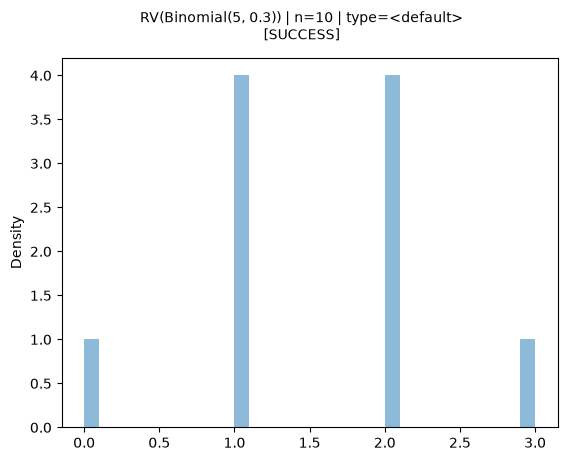

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=<default>


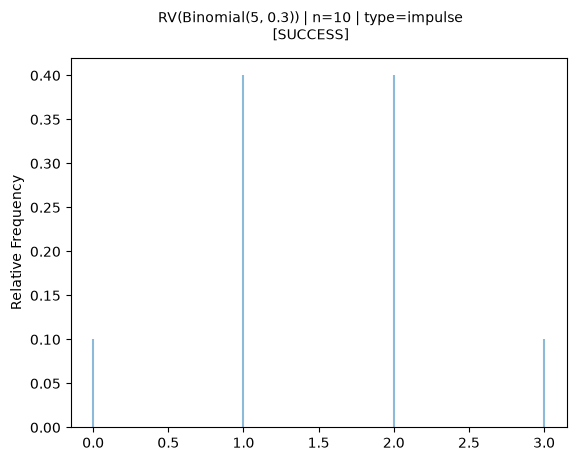

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=impulse


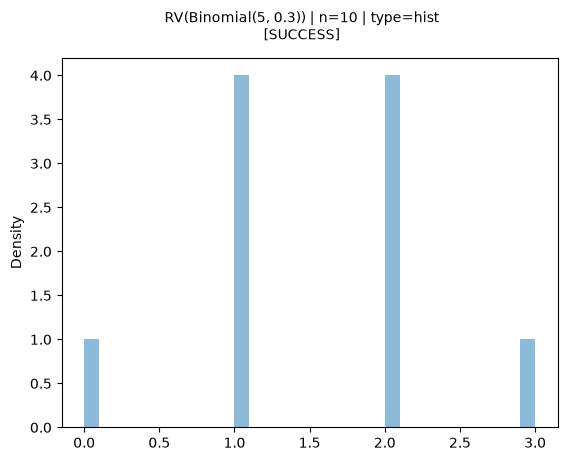

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=hist


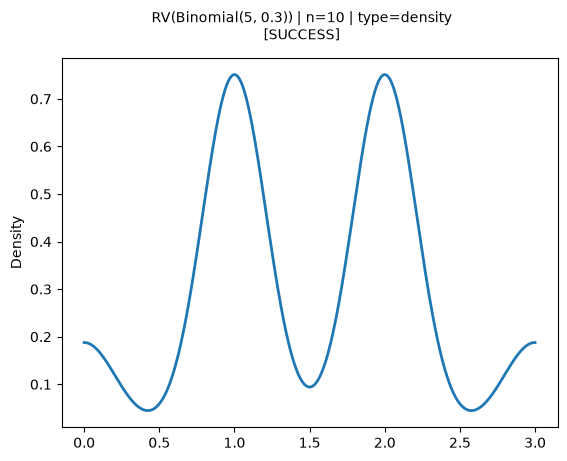

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=density


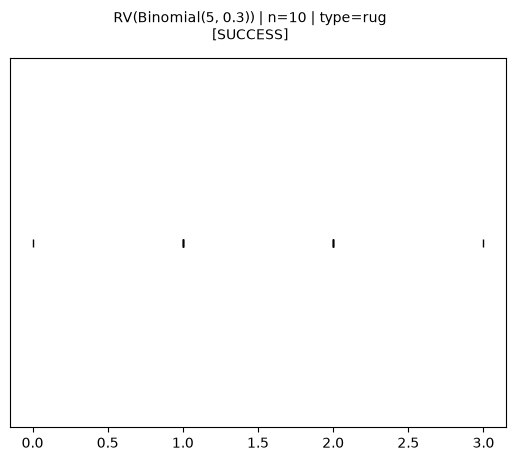

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=rug


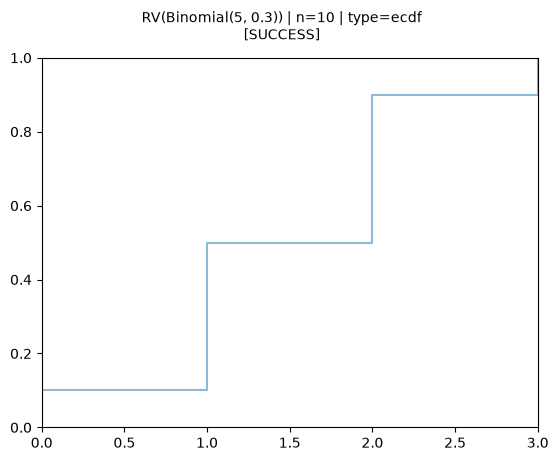

[SUCCESS] RV(Binomial(5, 0.3)) | n=10 | type=ecdf


In [6]:
seed(101)
r = RV(Binomial(5, 0.3)).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(5, 0.3))', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='1. 1D discrete-ish, small n')

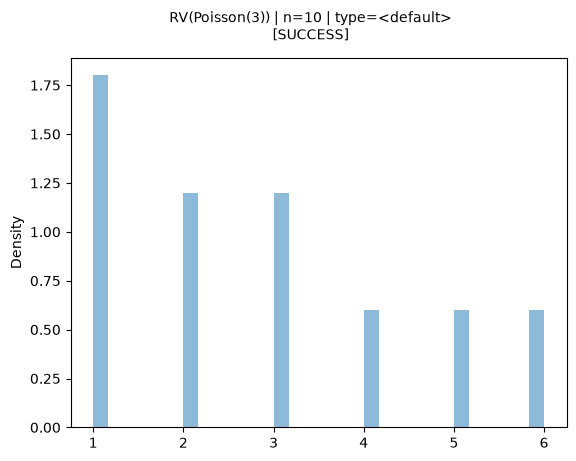

[SUCCESS] RV(Poisson(3)) | n=10 | type=<default>


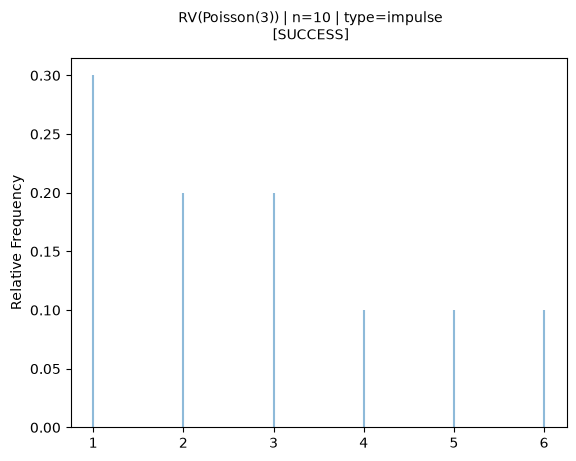

[SUCCESS] RV(Poisson(3)) | n=10 | type=impulse


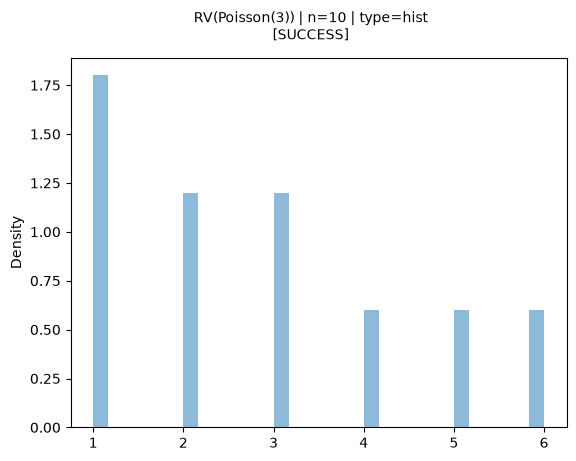

[SUCCESS] RV(Poisson(3)) | n=10 | type=hist


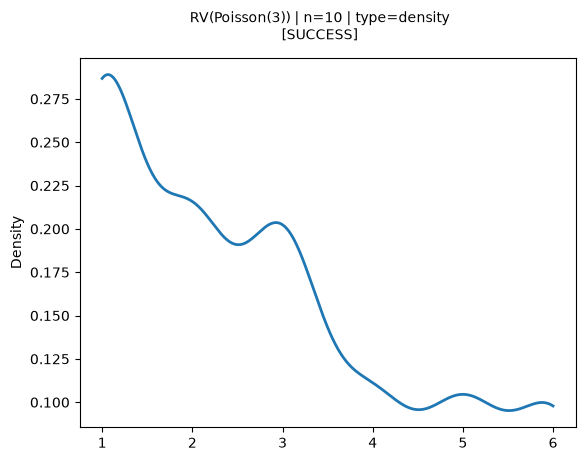

[SUCCESS] RV(Poisson(3)) | n=10 | type=density


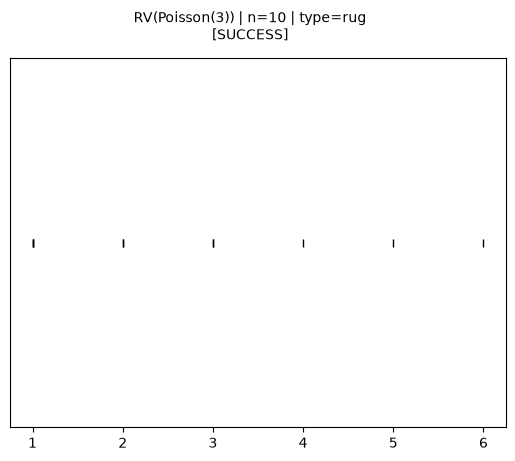

[SUCCESS] RV(Poisson(3)) | n=10 | type=rug


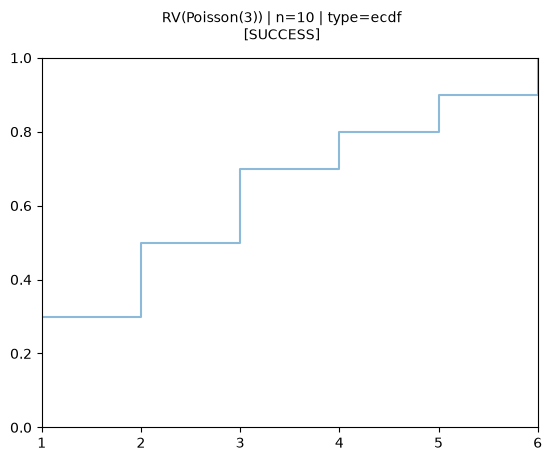

[SUCCESS] RV(Poisson(3)) | n=10 | type=ecdf


In [7]:
seed(102)
r = RV(Poisson(3)).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(3))', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='1. 1D discrete-ish, small n')

> **Documented correction.** The plan writes `BoxModel([1,2,3,4,5,6]).sim(10).plot()`. On the reference fork a bare `ProbabilitySpace.sim()` returns a `Results` object whose `.plot()` raises *“define an RV first”*. **Correction:** wrap in `RV(...)`. The raw behavior is shown first, then the `RV`-wrapped version that actually plots.

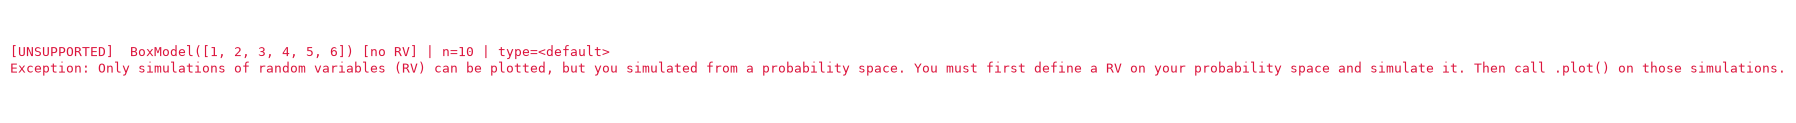

[UNSUPPORTED] BoxModel([1, 2, 3, 4, 5, 6]) [no RV] | n=10 | type=<default>  ->  Exception: Only simulations of random variables (RV) can be plotted, but you simulated from a probability space. You must first define a RV on your probability space and simulate it. Then call .plot() on those simulations.


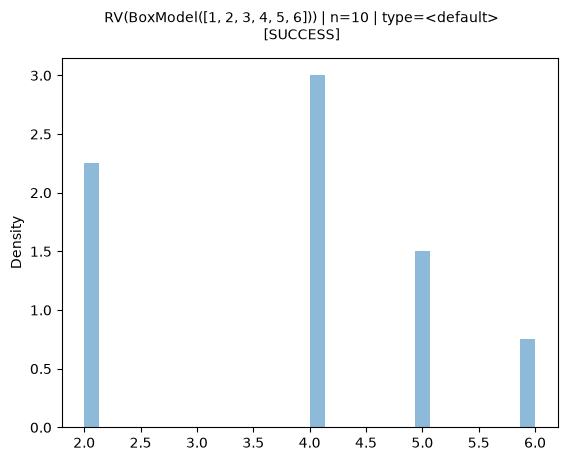

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=<default>


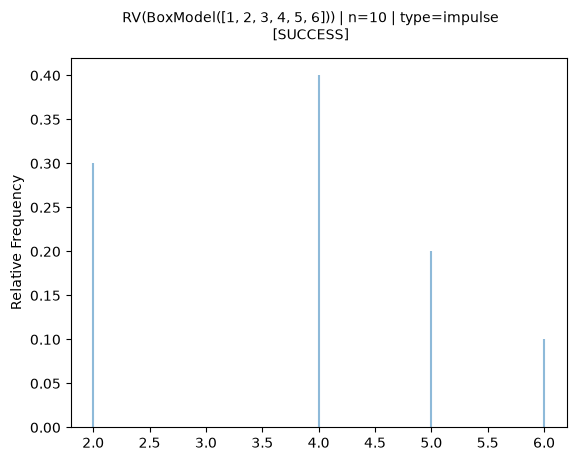

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=impulse


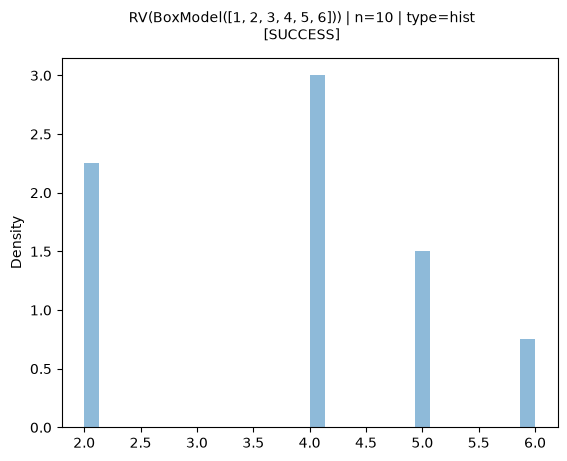

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=hist


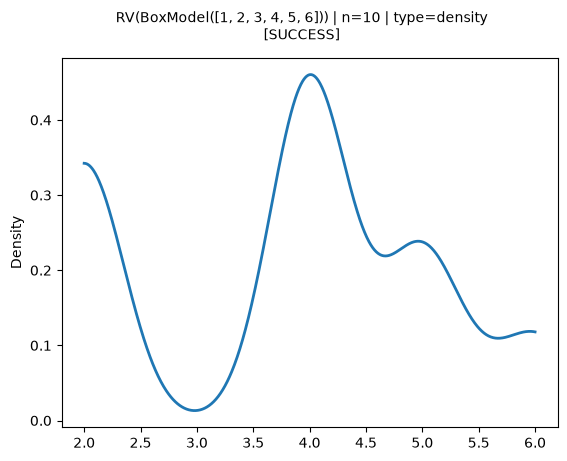

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=density


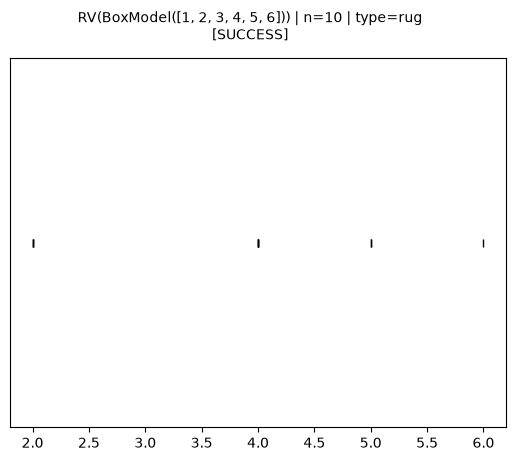

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=rug


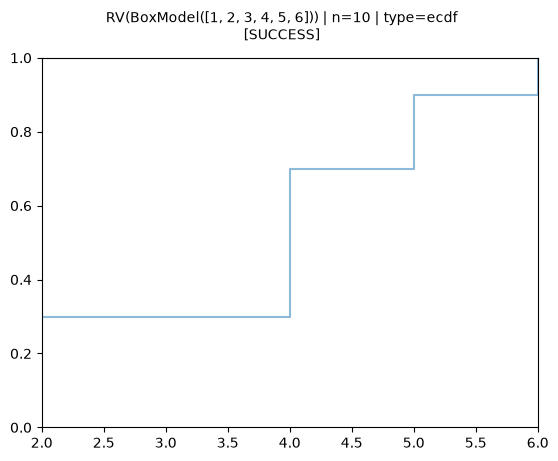

[SUCCESS] RV(BoxModel([1, 2, 3, 4, 5, 6])) | n=10 | type=ecdf


In [8]:
# Raw plan syntax (expected to raise: bare ProbabilitySpace.sim().plot())
seed(103)
raw = BoxModel([1, 2, 3, 4, 5, 6]).sim(10)
show('BoxModel([1, 2, 3, 4, 5, 6]) [no RV]', 10, raw, None, '1. 1D discrete-ish, small n')

# Corrected, plottable version:
seed(103)
r = RV(BoxModel([1, 2, 3, 4, 5, 6])).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(BoxModel([1, 2, 3, 4, 5, 6]))', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='1. 1D discrete-ish, small n')

### Observations — 1D discrete-ish, small n

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Binomial(5, 0.3)) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `BoxModel([1, 2, 3, 4, 5, 6]) [no RV] (n=10)` | `<default>` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(BoxModel([1, 2, 3, 4, 5, 6])) (n=10)` | `ecdf` | &#9989; yes |  |  |  |

## 2. 1D discrete-ish, large n

Large samples from discrete distributions. `RV(Poisson(20))` is the **borderline** case flagged in the plan (~35 support values); `RV(DiscreteUniform(1, 20))` has exactly 20 equally likely values.

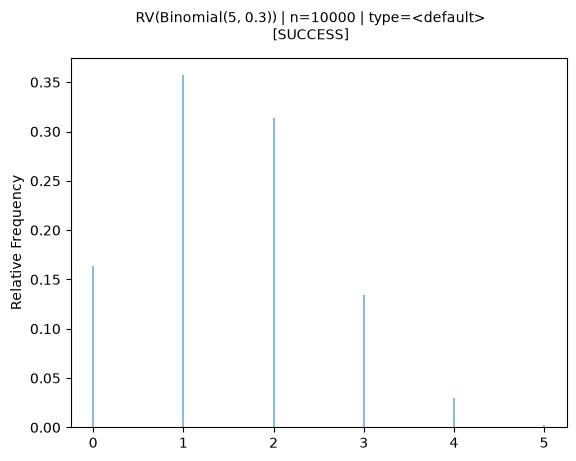

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=<default>


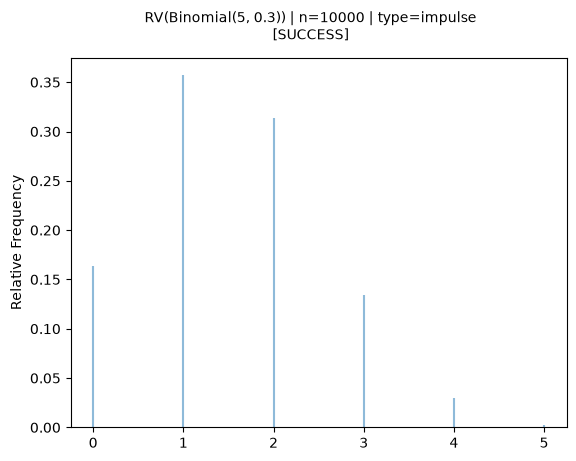

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=impulse


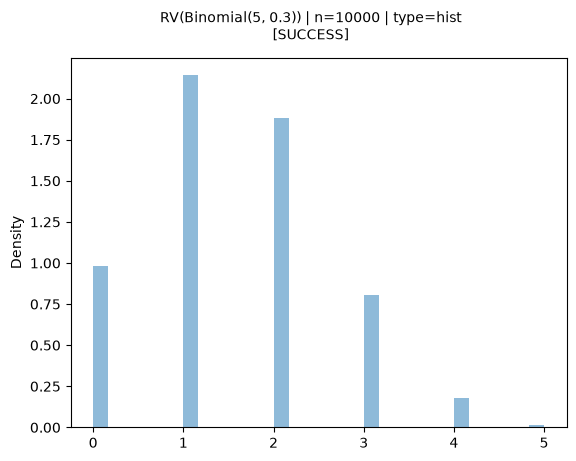

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=hist


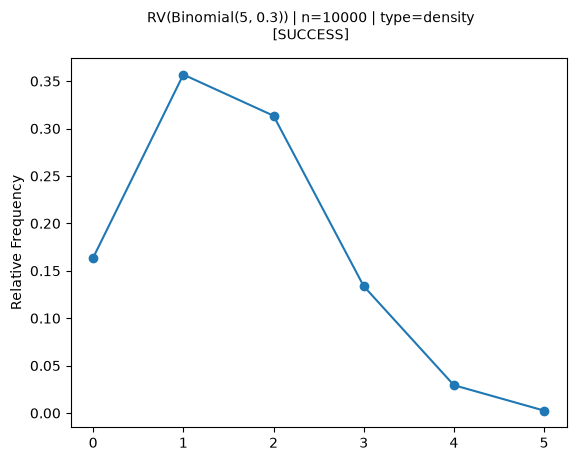

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=density


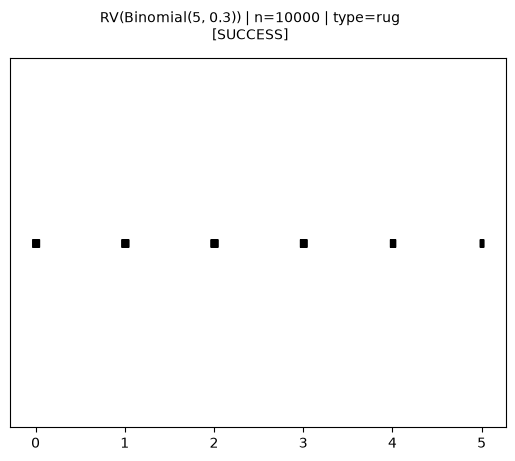

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=rug


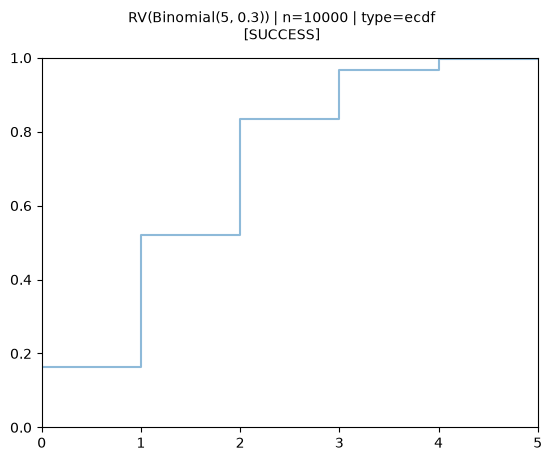

[SUCCESS] RV(Binomial(5, 0.3)) | n=10000 | type=ecdf


In [9]:
seed(111)
r = RV(Binomial(5, 0.3)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(5, 0.3))', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='2. 1D discrete-ish, large n')

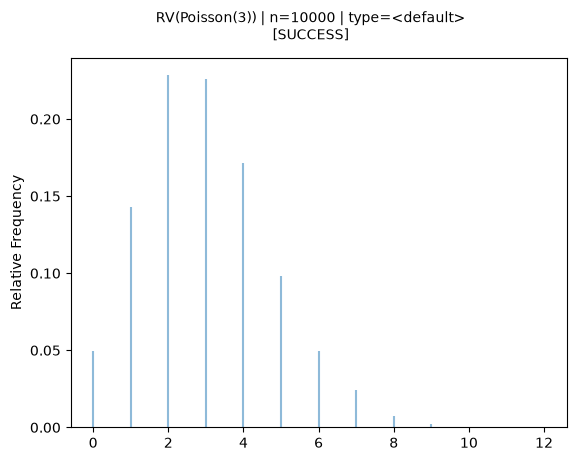

[SUCCESS] RV(Poisson(3)) | n=10000 | type=<default>


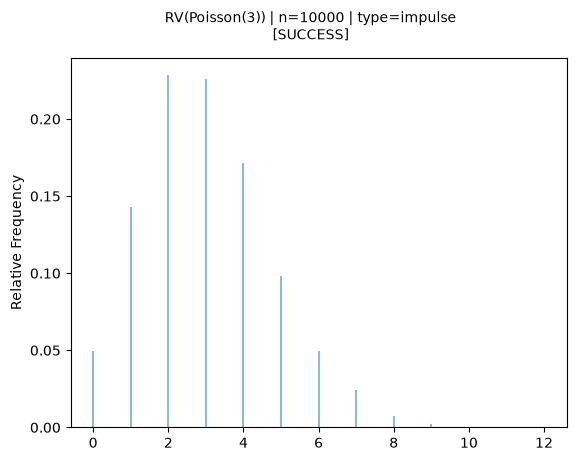

[SUCCESS] RV(Poisson(3)) | n=10000 | type=impulse


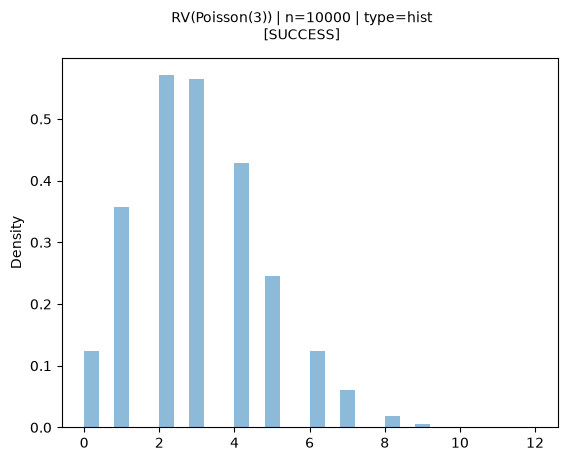

[SUCCESS] RV(Poisson(3)) | n=10000 | type=hist


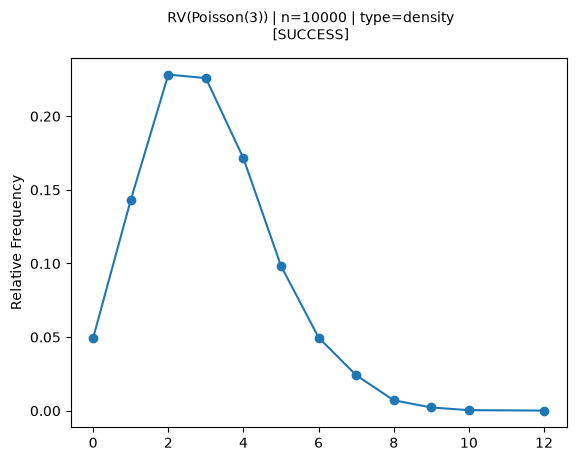

[SUCCESS] RV(Poisson(3)) | n=10000 | type=density


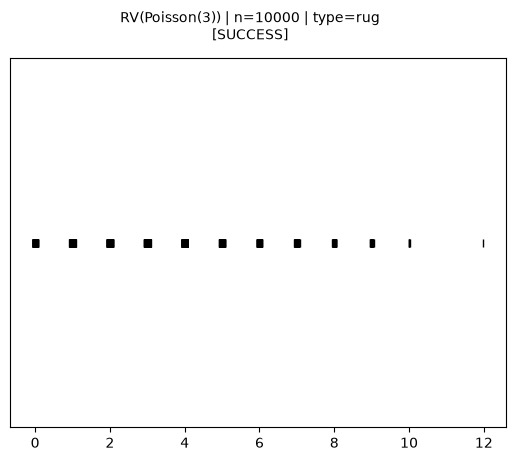

[SUCCESS] RV(Poisson(3)) | n=10000 | type=rug


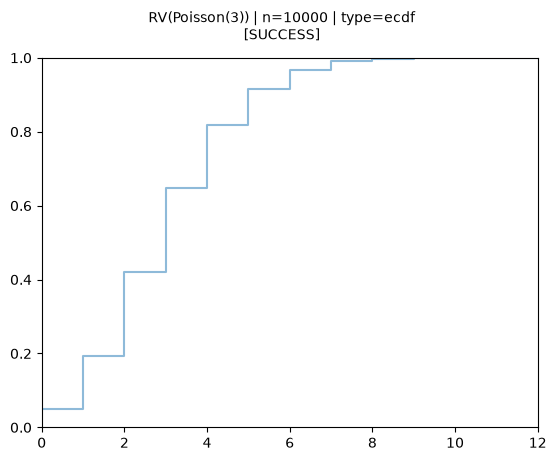

[SUCCESS] RV(Poisson(3)) | n=10000 | type=ecdf


In [10]:
seed(112)
r = RV(Poisson(3)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(3))', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='2. 1D discrete-ish, large n')

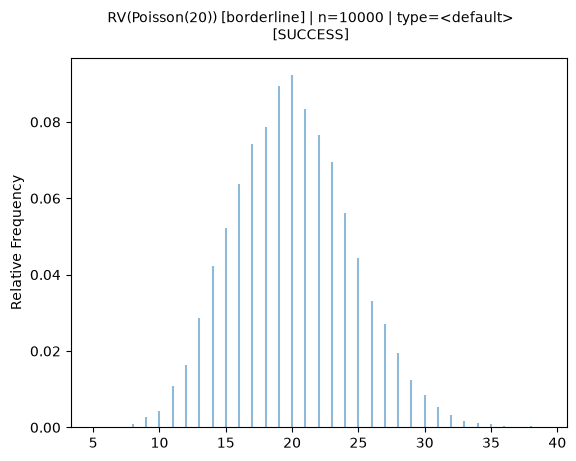

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=<default>


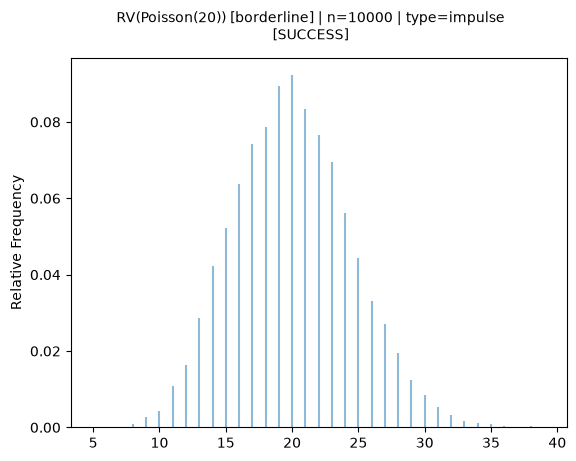

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=impulse


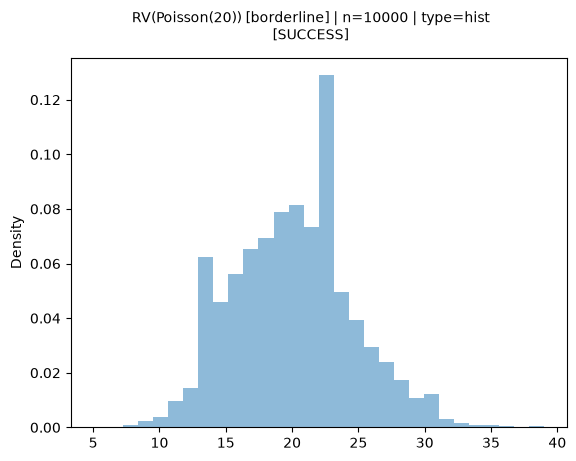

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=hist


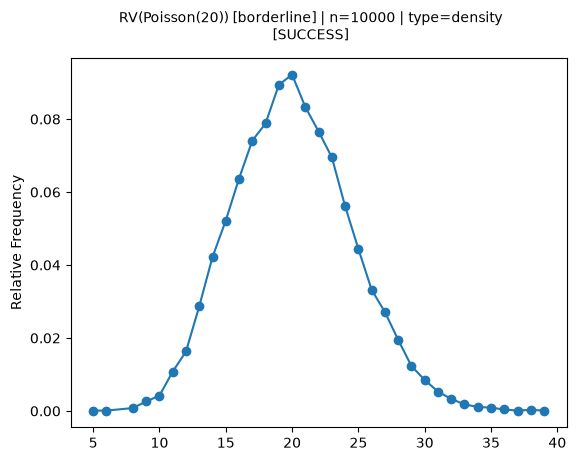

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=density


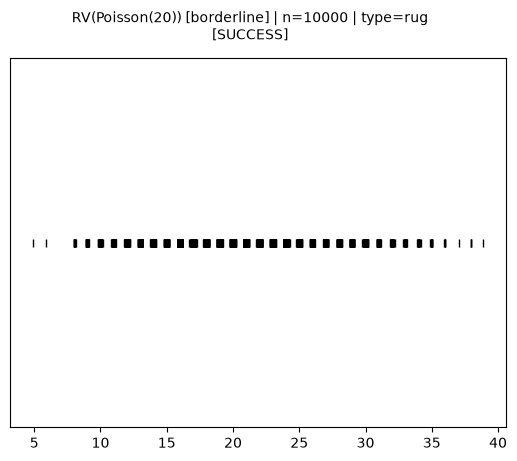

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=rug


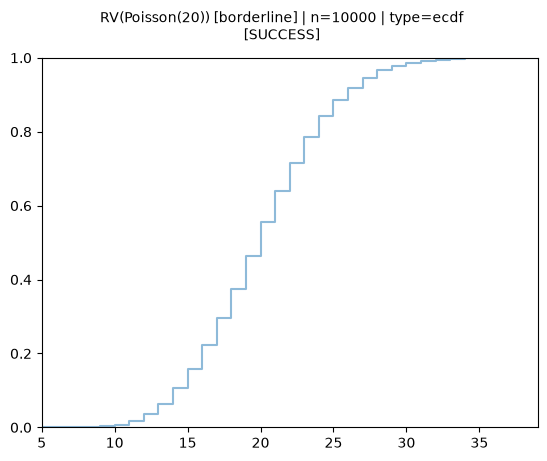

[SUCCESS] RV(Poisson(20)) [borderline] | n=10000 | type=ecdf


In [11]:
seed(113)
r = RV(Poisson(20)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(20)) [borderline]', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='2. 1D discrete-ish, large n')

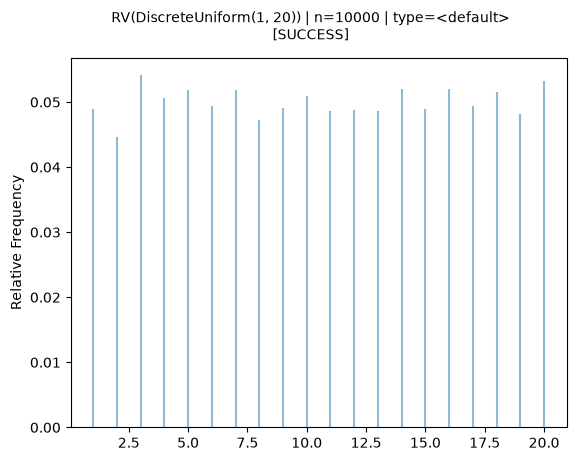

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=<default>


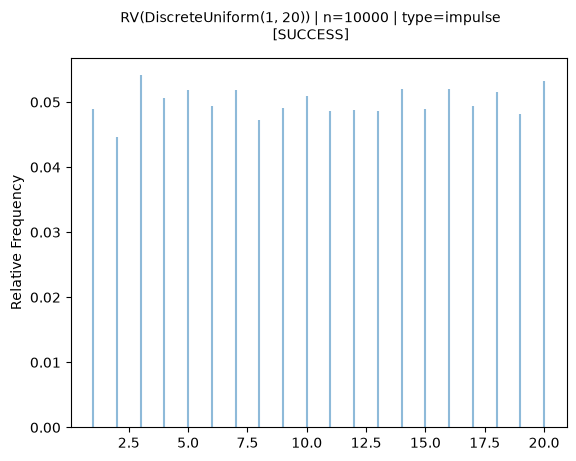

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=impulse


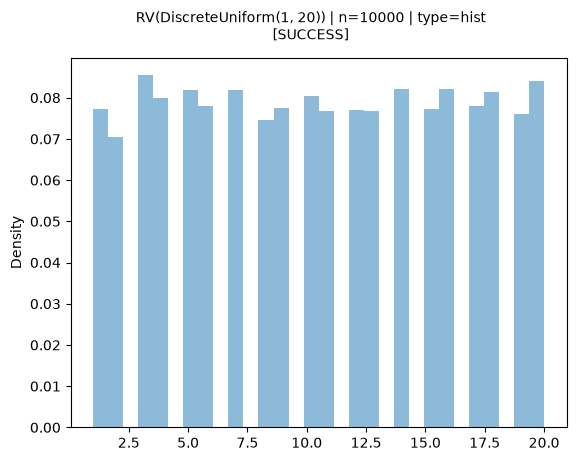

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=hist


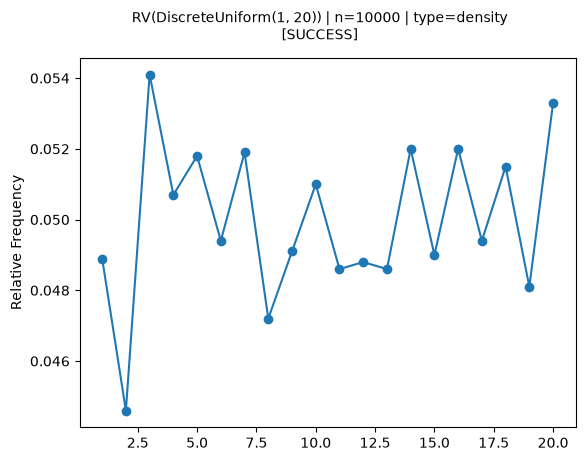

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=density


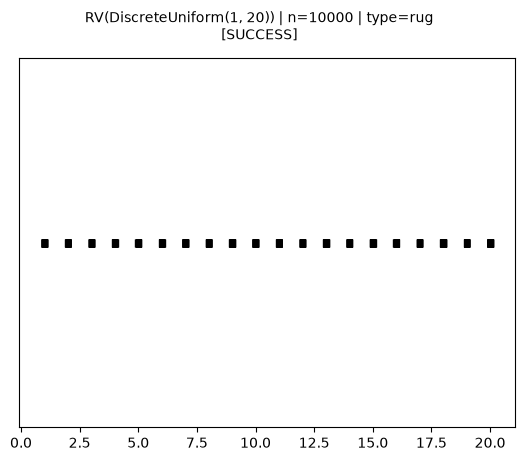

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=rug


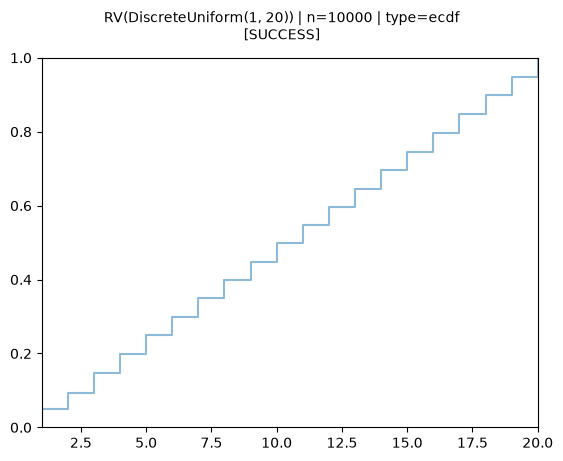

[SUCCESS] RV(DiscreteUniform(1, 20)) | n=10000 | type=ecdf


In [12]:
seed(114)
r = RV(DiscreteUniform(1, 20)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(DiscreteUniform(1, 20))', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='2. 1D discrete-ish, large n')

### Observations — 1D discrete-ish, large n

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Binomial(5, 0.3)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3)) (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Poisson(3)) (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Poisson(20)) [borderline] (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(DiscreteUniform(1, 20)) (n=10000)` | `ecdf` | &#9989; yes |  |  |  |

## 3. 1D continuous-ish, small n

Small samples from continuous distributions (values are essentially all unique at this `n`).

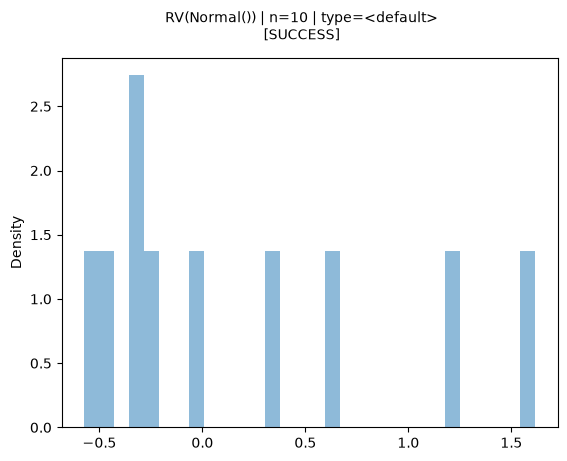

[SUCCESS] RV(Normal()) | n=10 | type=<default>


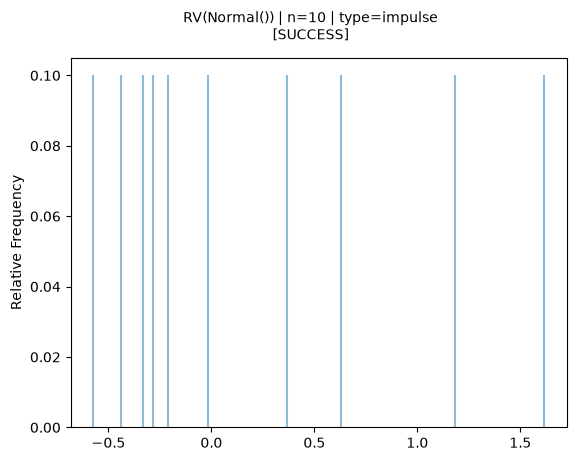

[SUCCESS] RV(Normal()) | n=10 | type=impulse


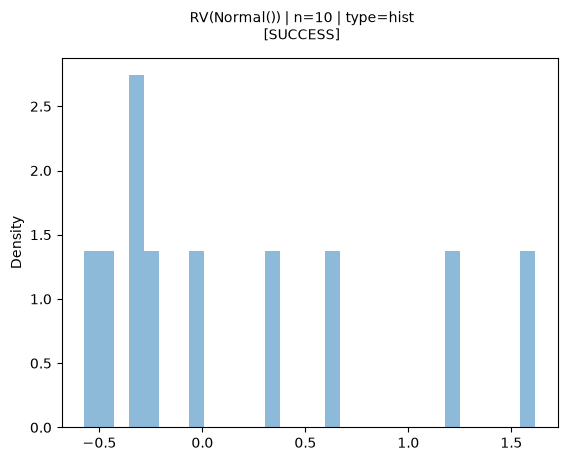

[SUCCESS] RV(Normal()) | n=10 | type=hist


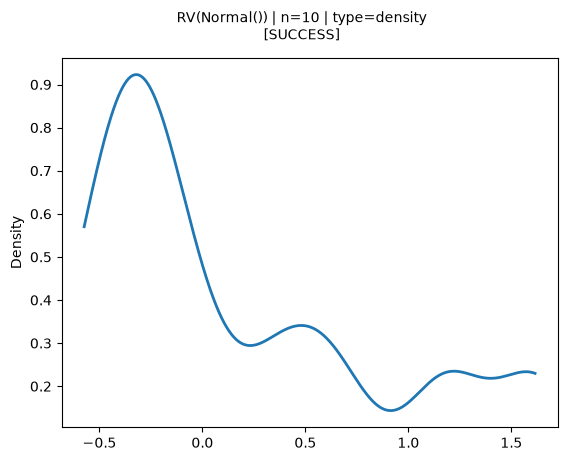

[SUCCESS] RV(Normal()) | n=10 | type=density


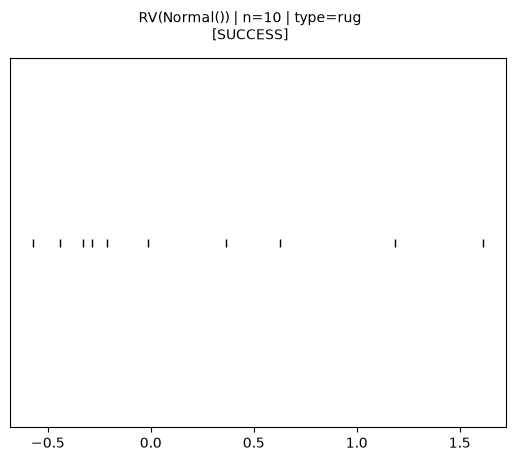

[SUCCESS] RV(Normal()) | n=10 | type=rug


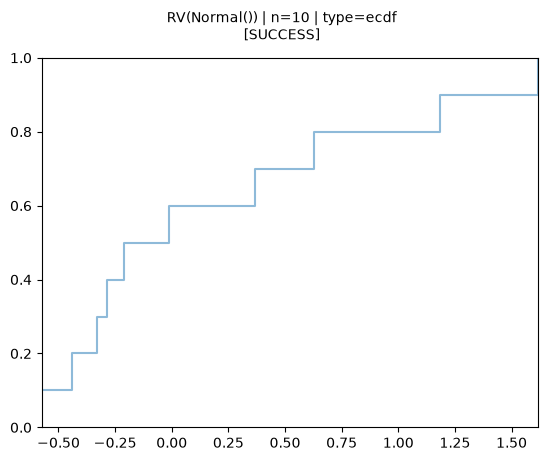

[SUCCESS] RV(Normal()) | n=10 | type=ecdf


In [13]:
seed(121)
r = RV(Normal()).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(Normal())', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='3. 1D continuous-ish, small n')

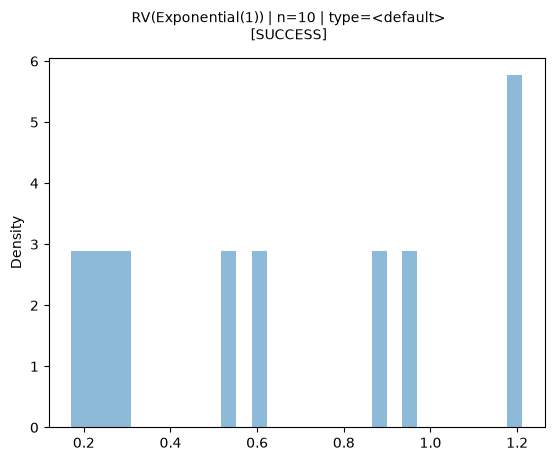

[SUCCESS] RV(Exponential(1)) | n=10 | type=<default>


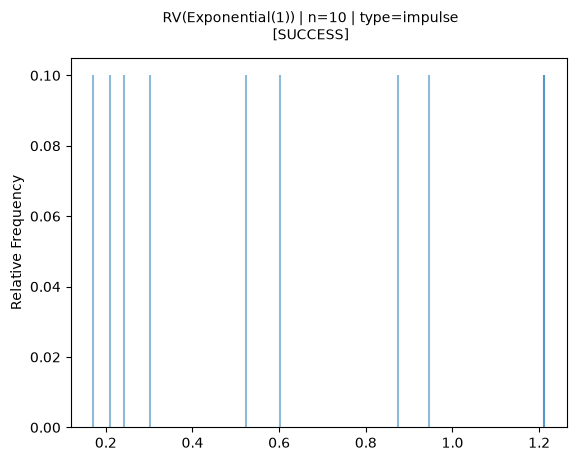

[SUCCESS] RV(Exponential(1)) | n=10 | type=impulse


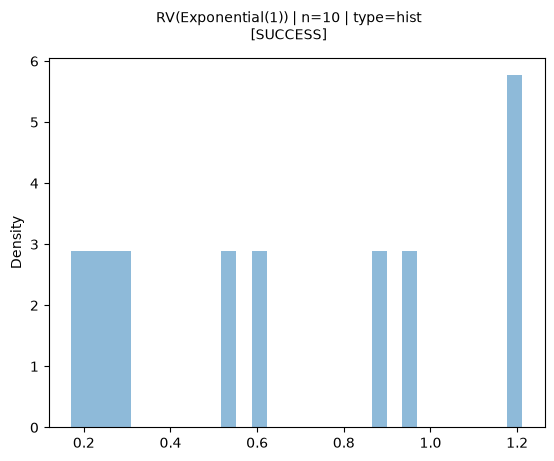

[SUCCESS] RV(Exponential(1)) | n=10 | type=hist


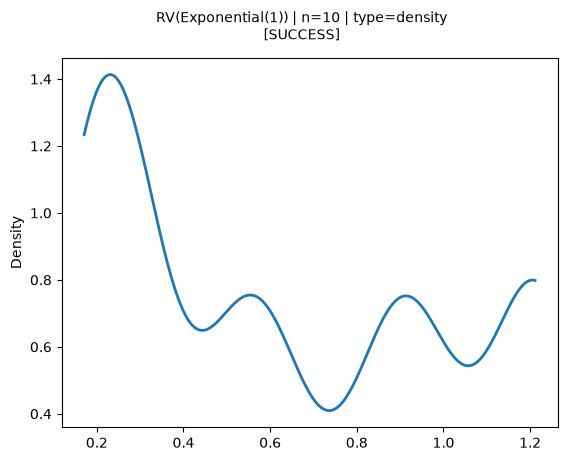

[SUCCESS] RV(Exponential(1)) | n=10 | type=density


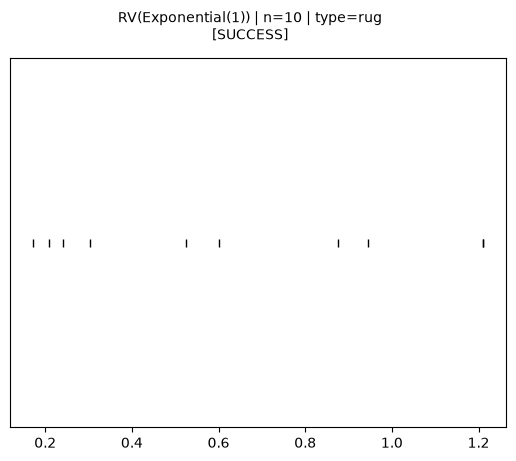

[SUCCESS] RV(Exponential(1)) | n=10 | type=rug


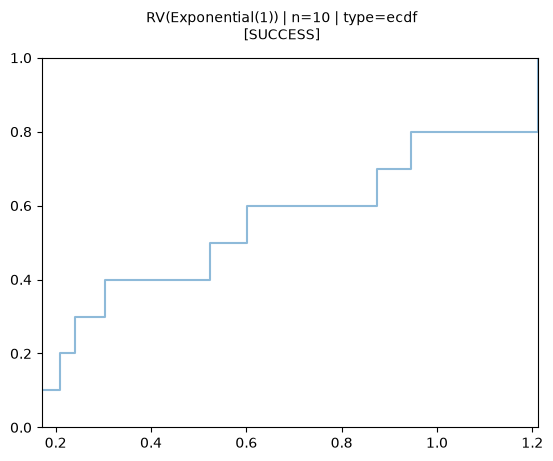

[SUCCESS] RV(Exponential(1)) | n=10 | type=ecdf


In [14]:
seed(122)
r = RV(Exponential(1)).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(Exponential(1))', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='3. 1D continuous-ish, small n')

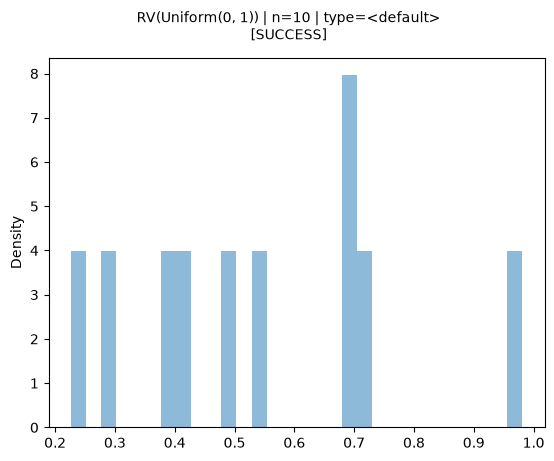

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=<default>


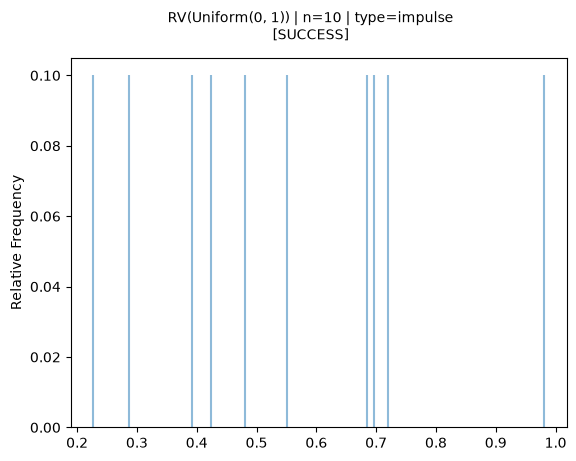

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=impulse


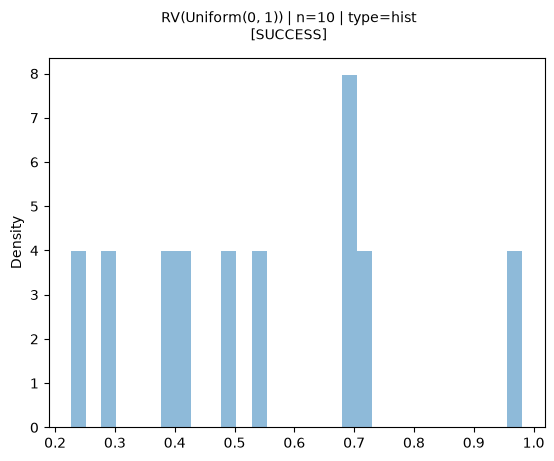

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=hist


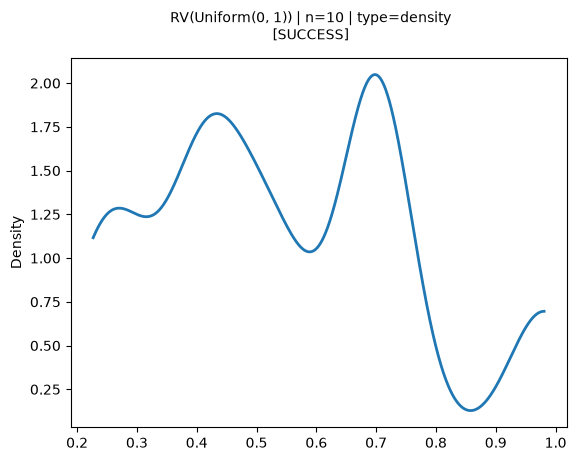

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=density


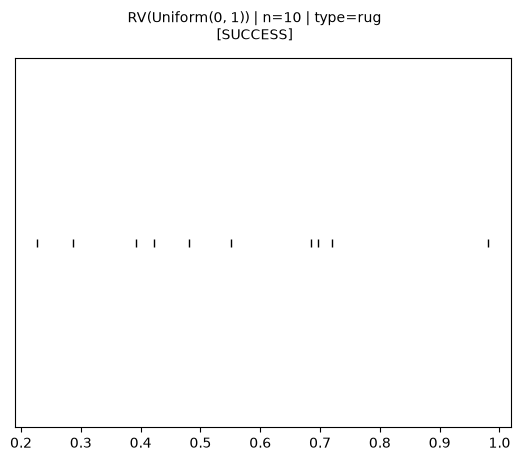

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=rug


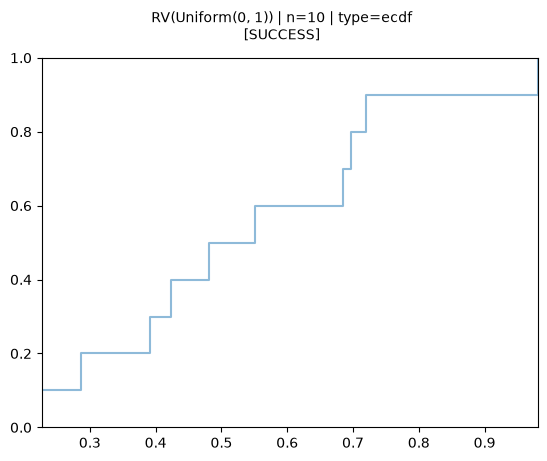

[SUCCESS] RV(Uniform(0, 1)) | n=10 | type=ecdf


In [15]:
seed(123)
r = RV(Uniform(0, 1)).sim(10)          # built once, reused across all plot types
sweep(r, base='RV(Uniform(0, 1))', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='3. 1D continuous-ish, small n')

### Observations — 1D continuous-ish, small n

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Normal()) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `hist` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `density` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `rug` | &#9989; yes |  |  |  |
| `RV(Uniform(0, 1)) (n=10)` | `ecdf` | &#9989; yes |  |  |  |

## 4. 1D continuous-ish, large n

Large samples from continuous distributions. `RV(Binomial(10000, 0.5))` is the *discrete-but-continuous-ish* borderline: hundreds of integer values, so the old `is_discrete()` may still call it discrete and default to a very dense `impulse` plot.

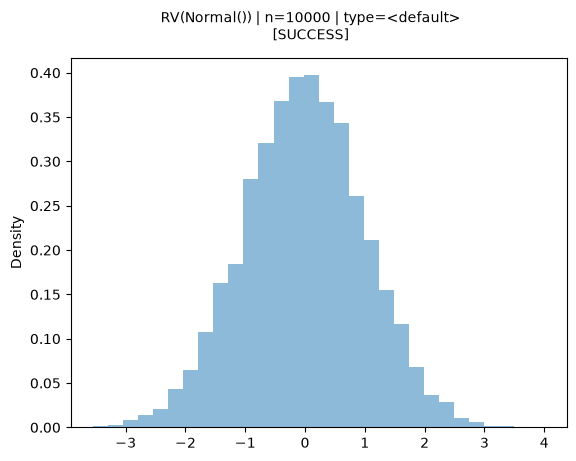

[SUCCESS] RV(Normal()) | n=10000 | type=<default>


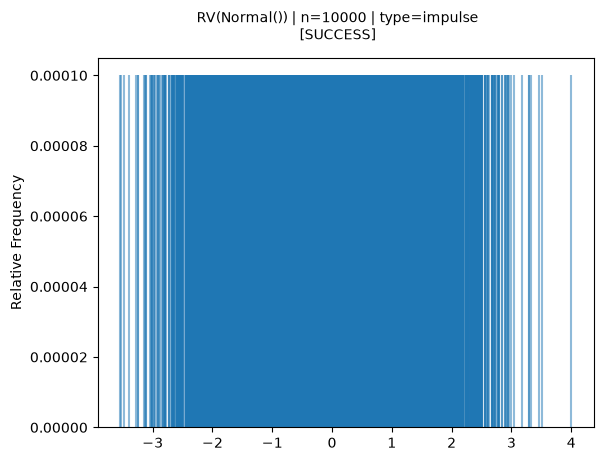

[SUCCESS] RV(Normal()) | n=10000 | type=impulse


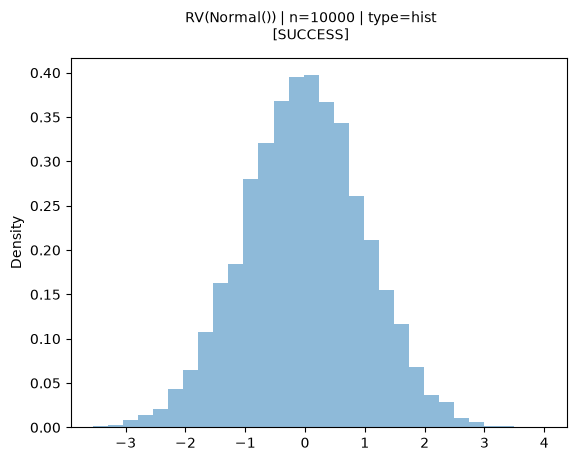

[SUCCESS] RV(Normal()) | n=10000 | type=hist


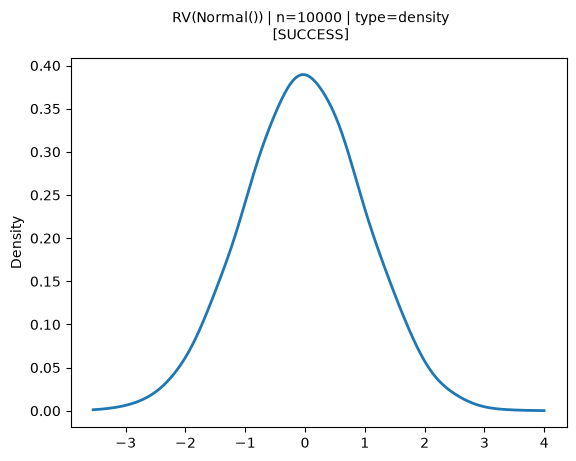

[SUCCESS] RV(Normal()) | n=10000 | type=density


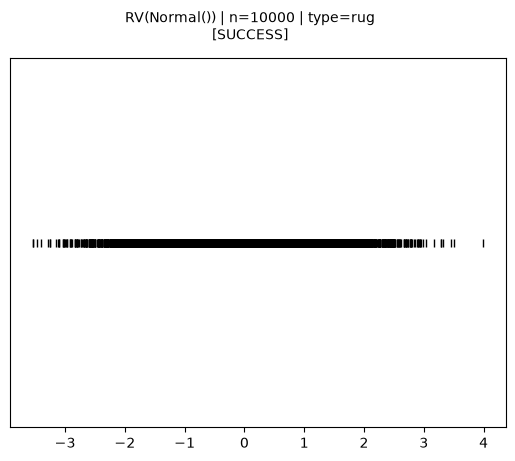

[SUCCESS] RV(Normal()) | n=10000 | type=rug


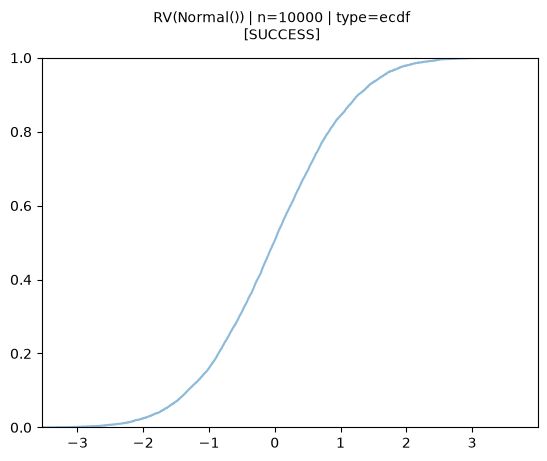

[SUCCESS] RV(Normal()) | n=10000 | type=ecdf


In [16]:
seed(131)
r = RV(Normal()).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Normal())', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='4. 1D continuous-ish, large n')

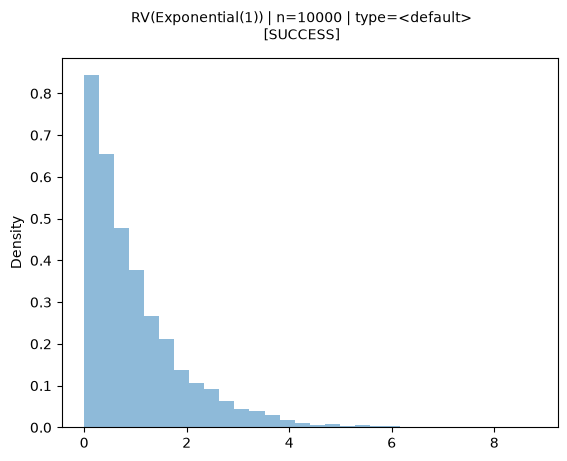

[SUCCESS] RV(Exponential(1)) | n=10000 | type=<default>


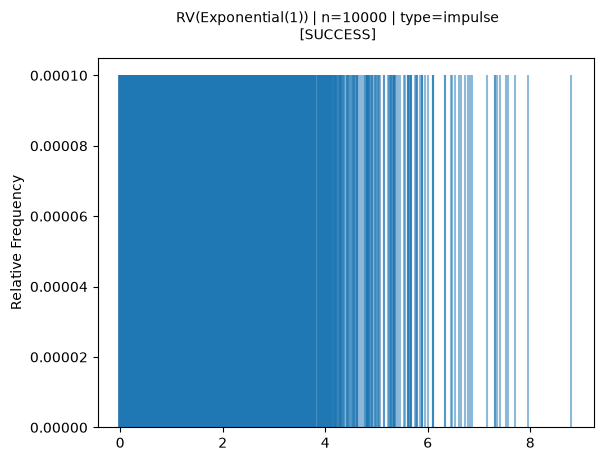

[SUCCESS] RV(Exponential(1)) | n=10000 | type=impulse


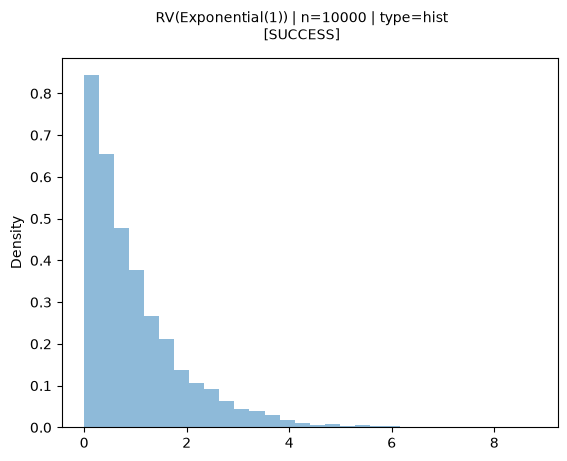

[SUCCESS] RV(Exponential(1)) | n=10000 | type=hist


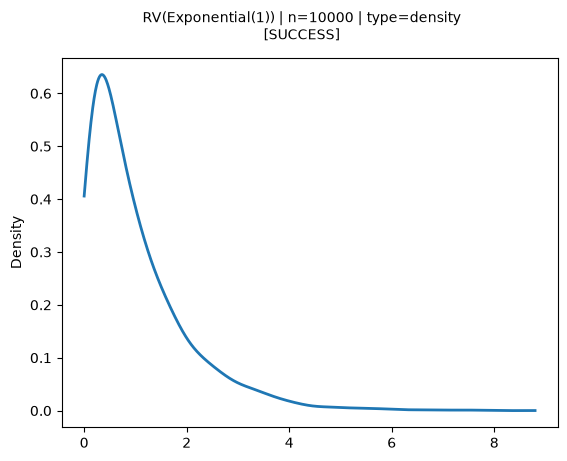

[SUCCESS] RV(Exponential(1)) | n=10000 | type=density


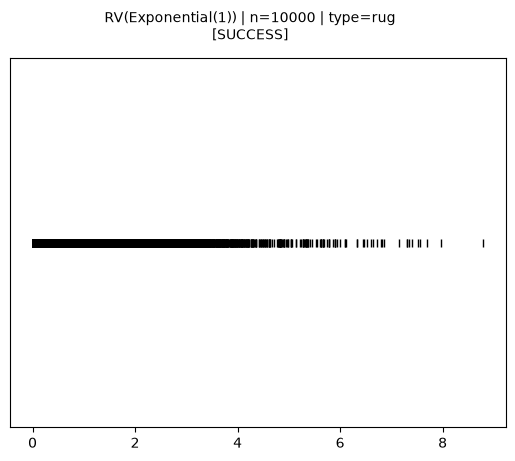

[SUCCESS] RV(Exponential(1)) | n=10000 | type=rug


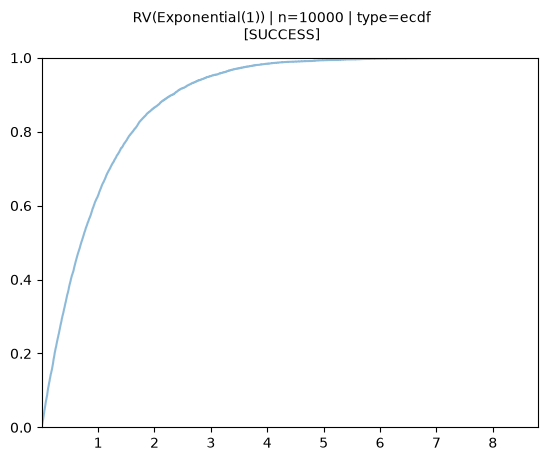

[SUCCESS] RV(Exponential(1)) | n=10000 | type=ecdf


In [17]:
seed(132)
r = RV(Exponential(1)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Exponential(1))', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='4. 1D continuous-ish, large n')

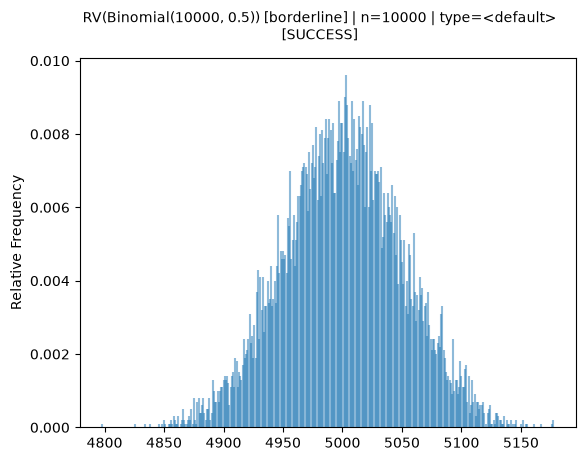

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=<default>


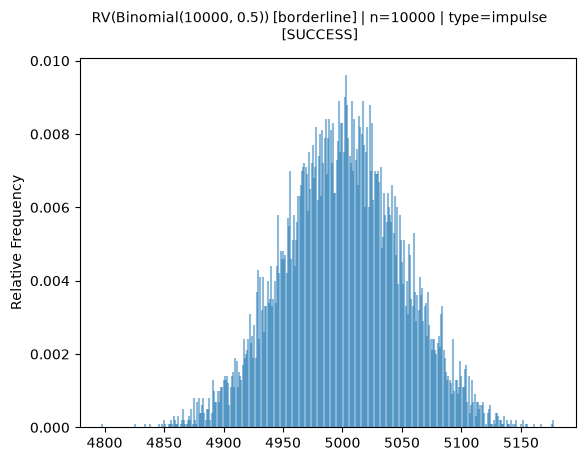

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=impulse


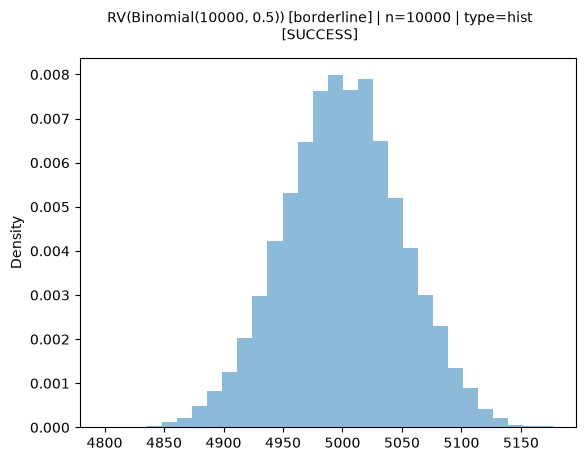

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=hist


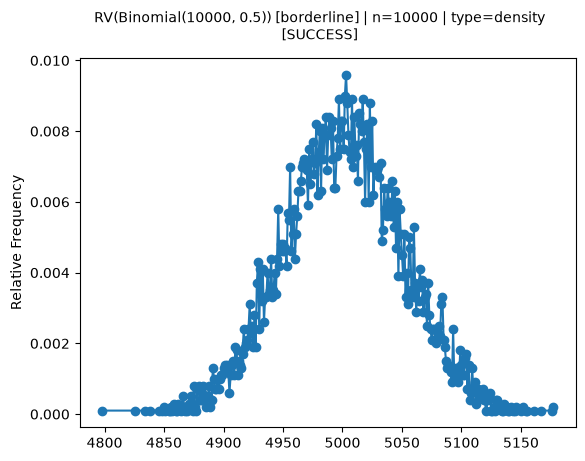

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=density


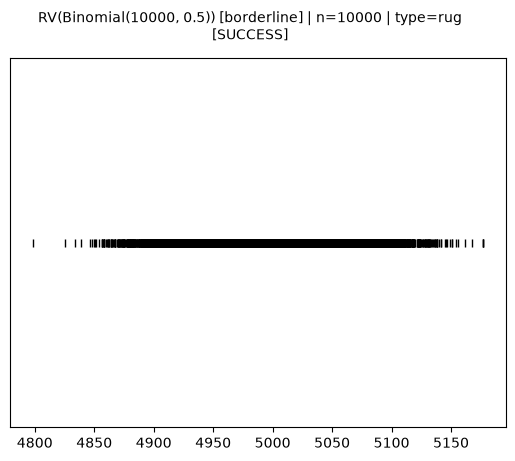

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=rug


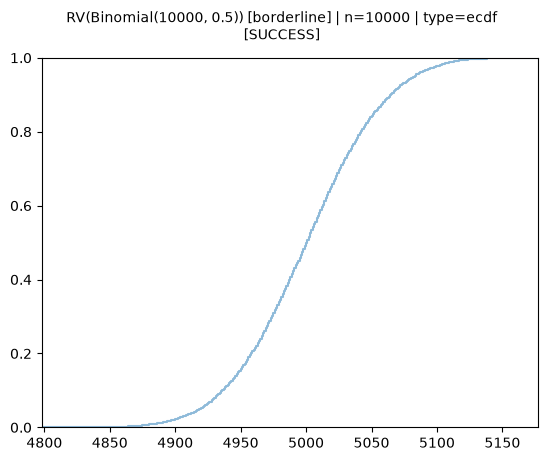

[SUCCESS] RV(Binomial(10000, 0.5)) [borderline] | n=10000 | type=ecdf


In [18]:
seed(133)
r = RV(Binomial(10000, 0.5)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(10000, 0.5)) [borderline]', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='4. 1D continuous-ish, large n')

### Observations — 1D continuous-ish, large n

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Normal()) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Normal()) (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Exponential(1)) (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `RV(Binomial(10000, 0.5)) [borderline] (n=10000)` | `ecdf` | &#9989; yes |  |  |  |

## 5. 2D discrete × discrete

Both coordinates discrete. `mosaic` is meaningful here (and **only** here); `violin` needs one continuous axis, so it renders **empty**. All 2D types are swept so you can see which apply.

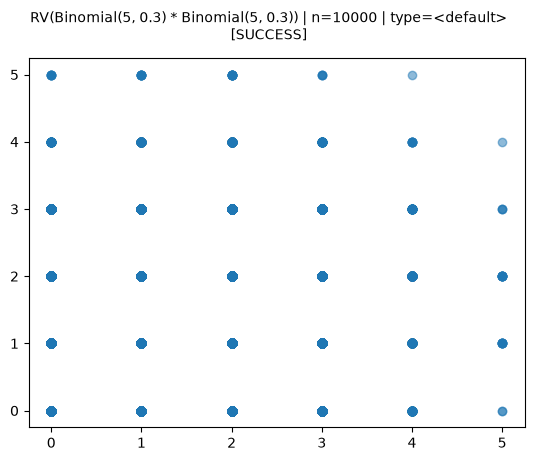

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=<default>


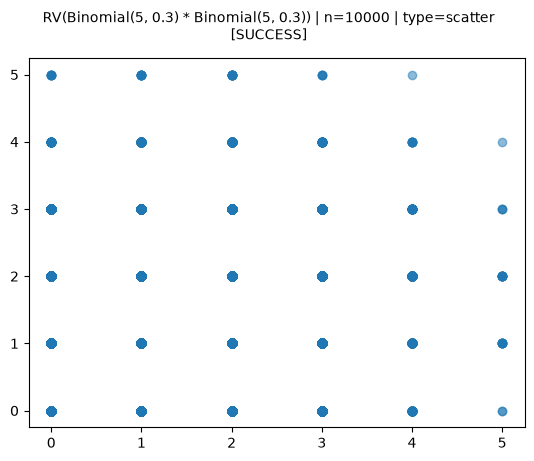

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=scatter


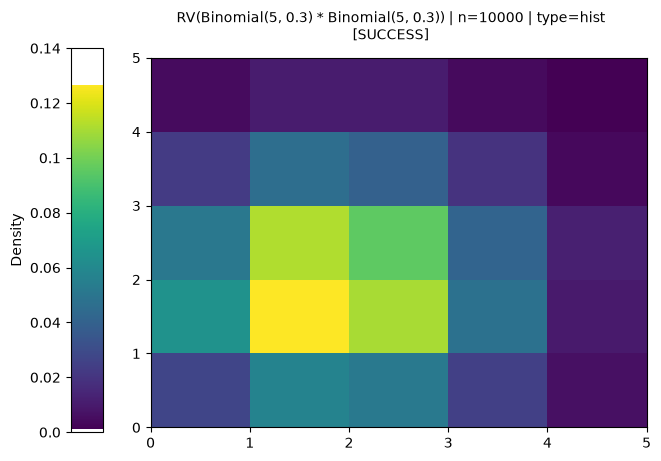

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=hist


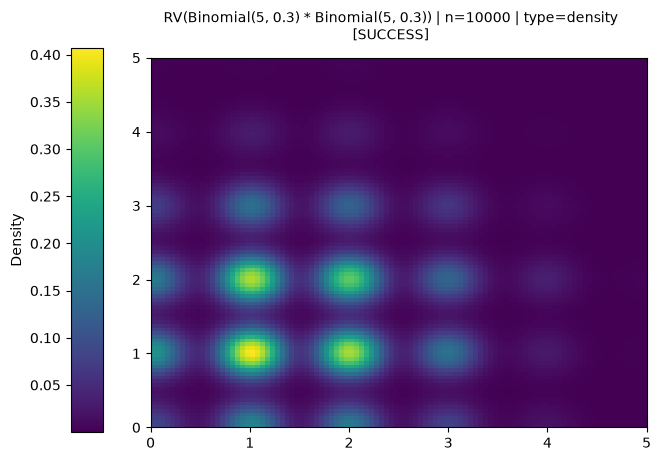

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=density


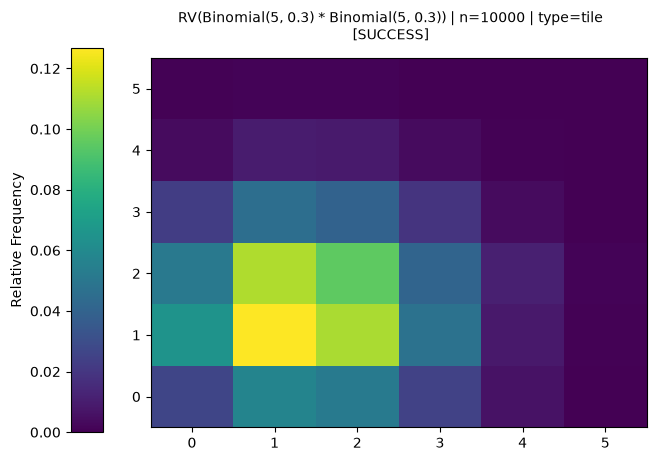

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=tile


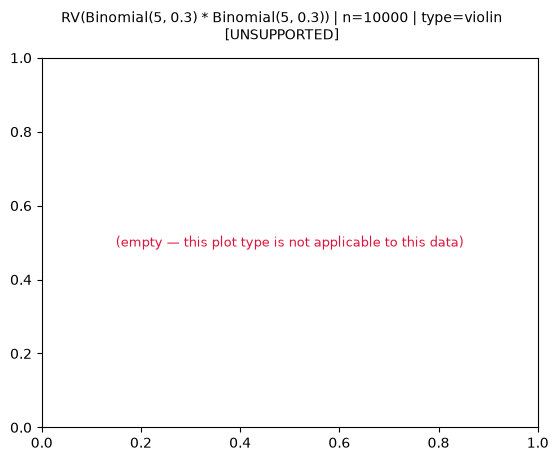

[UNSUPPORTED] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=violin


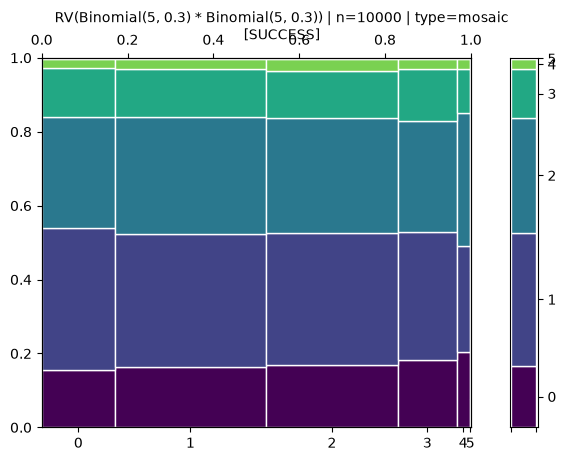

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=mosaic


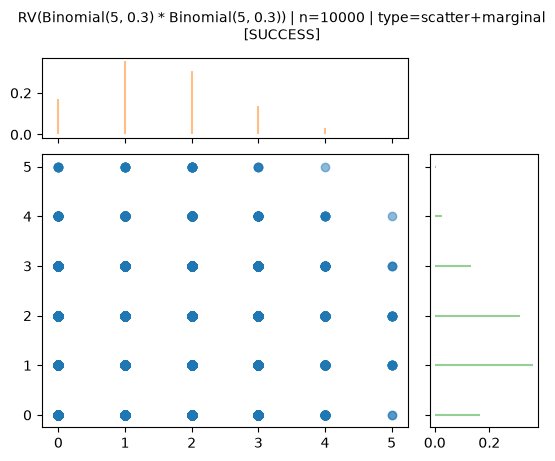

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=10000 | type=scatter+marginal


In [19]:
seed(141)
r = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(5, 0.3) * Binomial(5, 0.3))', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='5. 2D discrete × discrete')

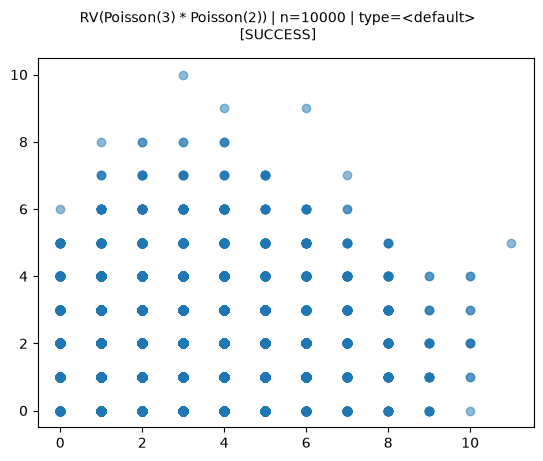

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=<default>


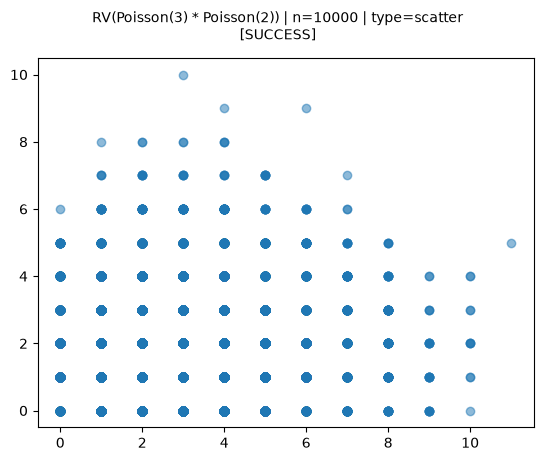

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=scatter


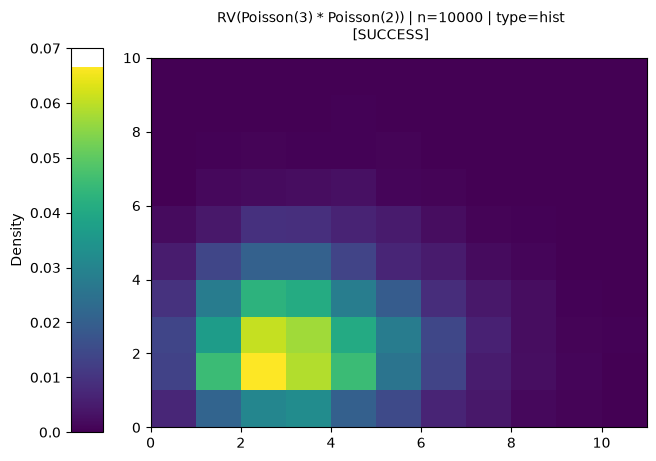

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=hist


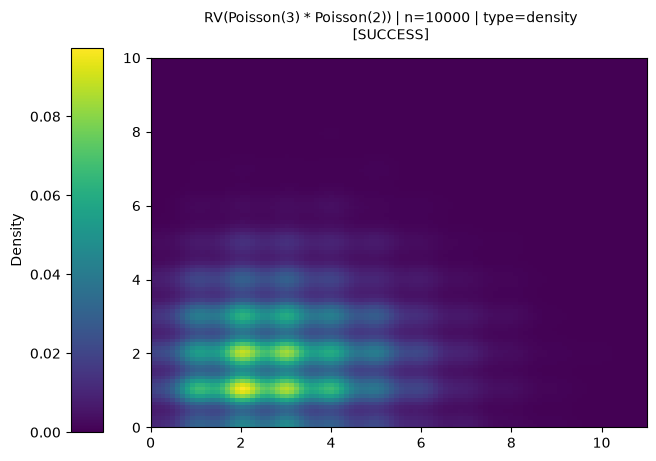

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=density


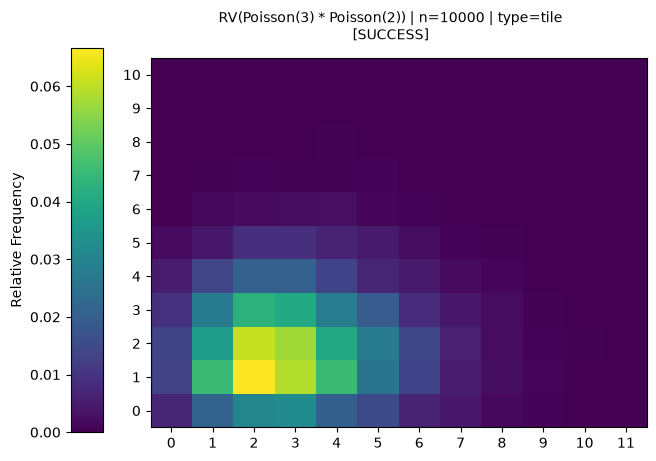

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=tile


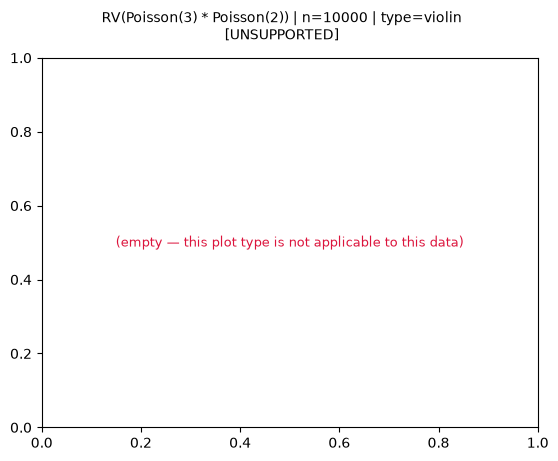

[UNSUPPORTED] RV(Poisson(3) * Poisson(2)) | n=10000 | type=violin


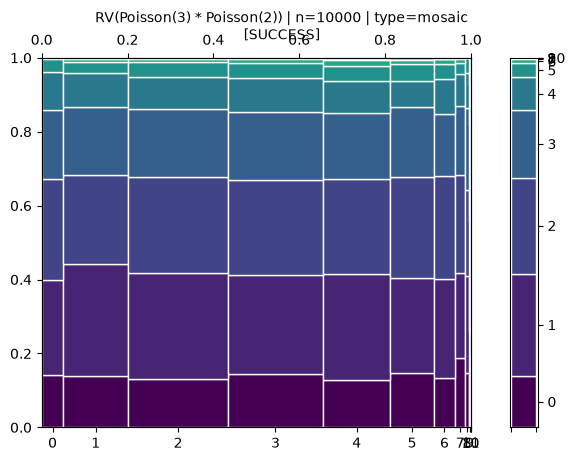

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=mosaic


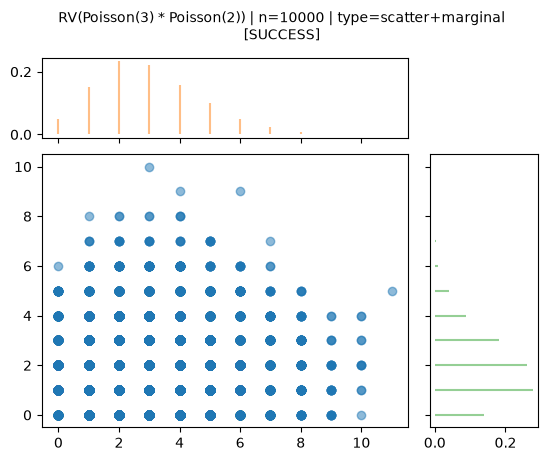

[SUCCESS] RV(Poisson(3) * Poisson(2)) | n=10000 | type=scatter+marginal


In [20]:
seed(142)
r = RV(Poisson(3) * Poisson(2)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(3) * Poisson(2))', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='5. 2D discrete × discrete')

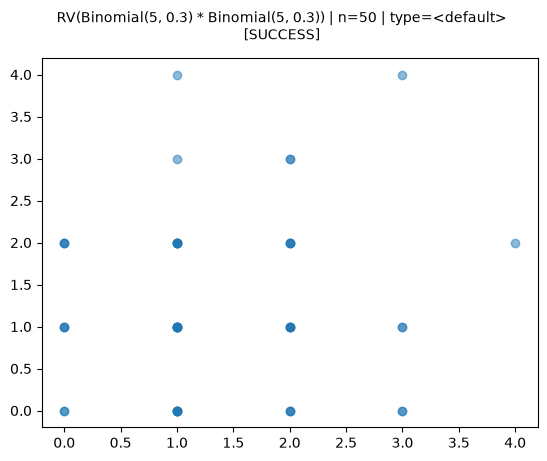

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=<default>


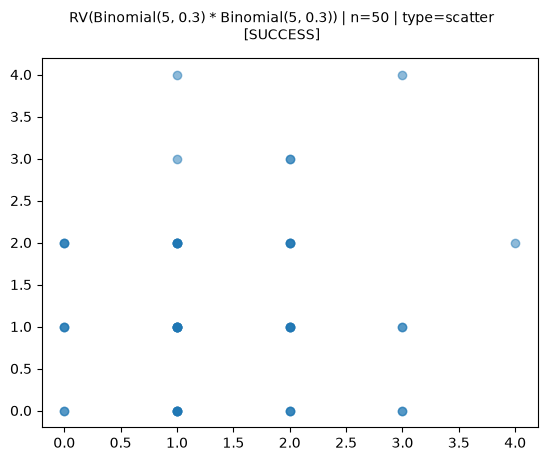

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=scatter


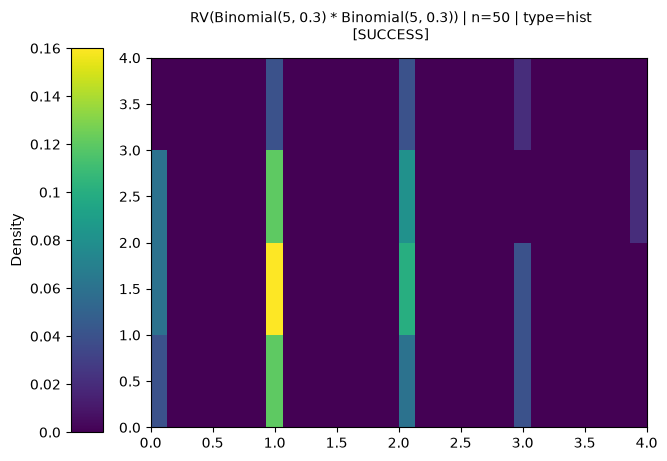

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=hist


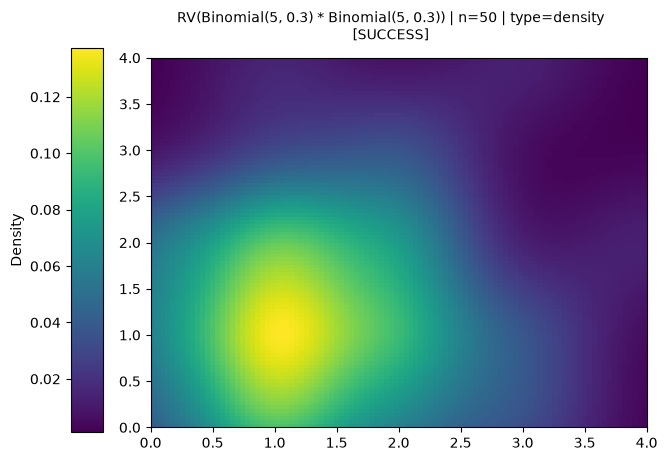

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=density


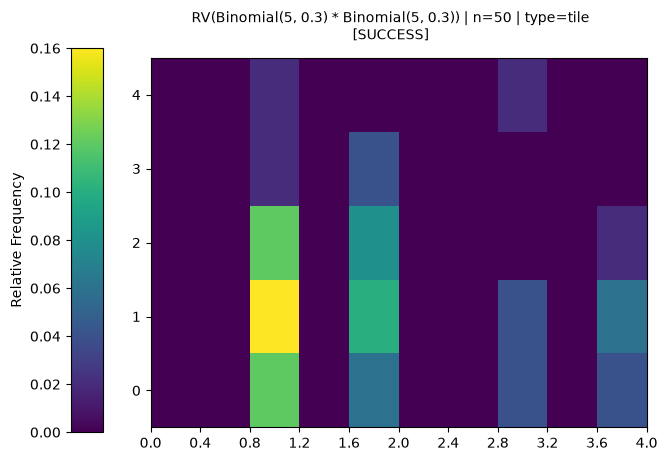

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=tile


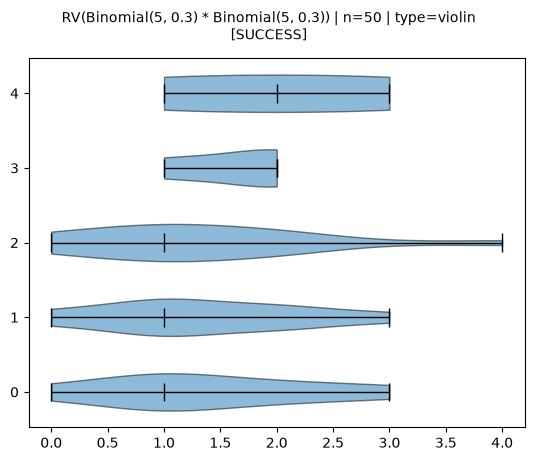

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=violin


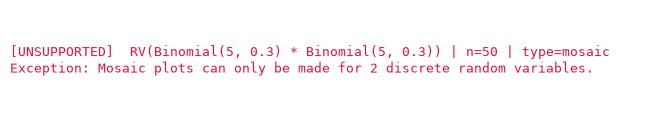

[UNSUPPORTED] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


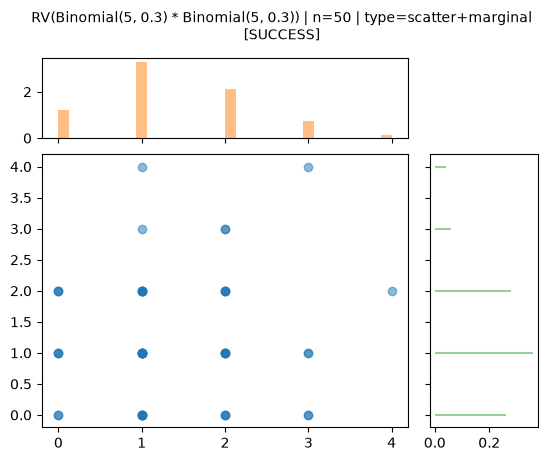

[SUCCESS] RV(Binomial(5, 0.3) * Binomial(5, 0.3)) | n=50 | type=scatter+marginal


In [21]:
seed(143)
r = RV(Binomial(5, 0.3) * Binomial(5, 0.3)).sim(50)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(5, 0.3) * Binomial(5, 0.3))', n=50, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='5. 2D discrete × discrete')

### Observations — 2D discrete × discrete

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `violin` | &#11036; empty (n/a) |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `mosaic` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `violin` | &#11036; empty (n/a) |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `mosaic` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Poisson(2)) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `tile` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `violin` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Binomial(5, 0.3) * Binomial(5, 0.3)) (n=50)` | `scatter+marginal` | &#9989; yes |  |  |  |

## 6. 2D continuous × continuous

Both coordinates continuous. `density` and `scatter`/`marginal` shine here; `mosaic` **raises** (needs two discrete) and `violin` renders **empty**. The `BivariateNormal()` example also sweeps `['density','marginal']` and `['tile','marginal']`.

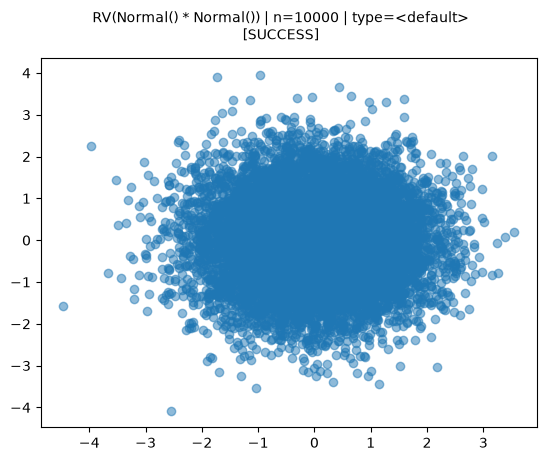

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=<default>


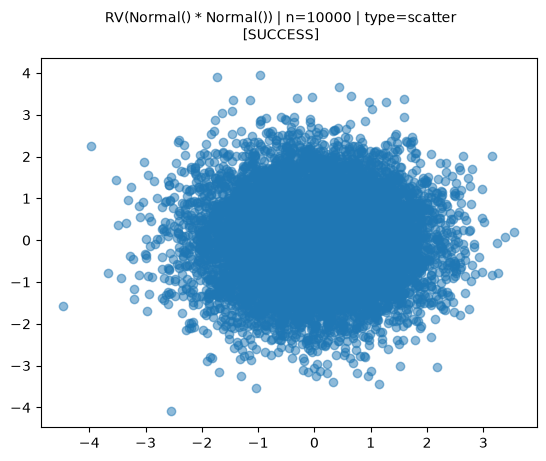

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=scatter


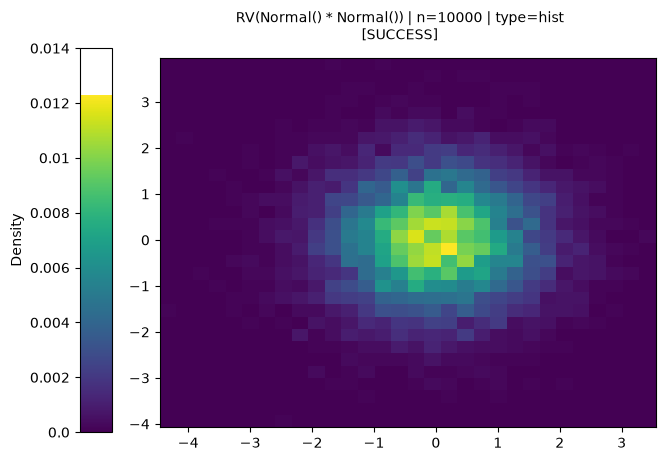

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=hist


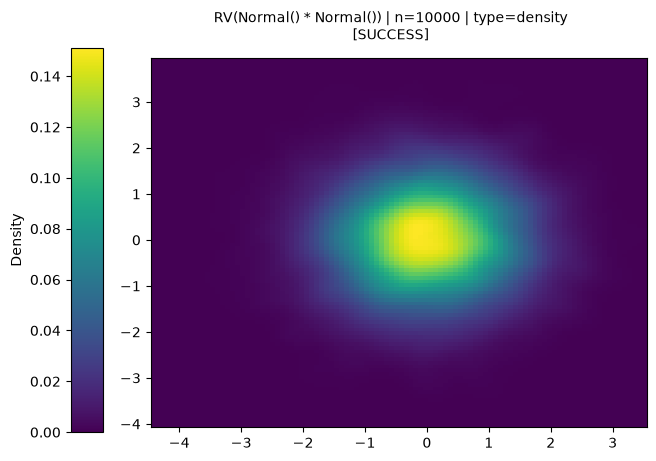

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=density


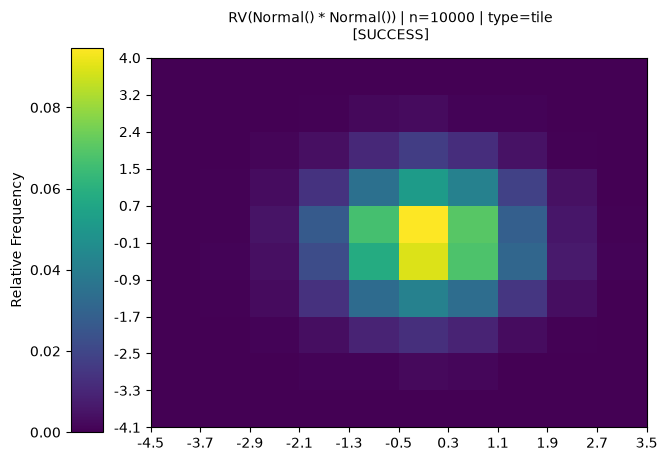

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=tile


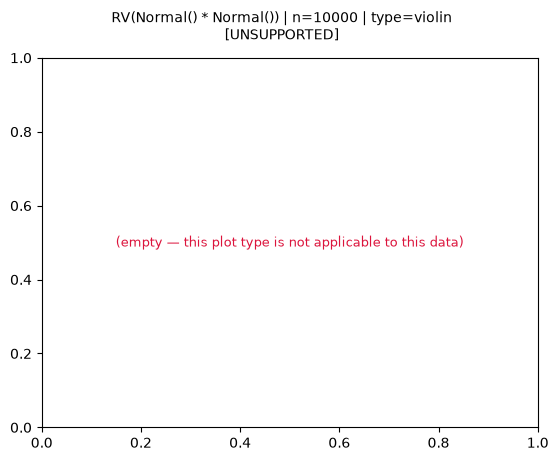

[UNSUPPORTED] RV(Normal() * Normal()) | n=10000 | type=violin


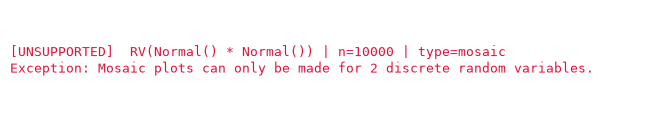

[UNSUPPORTED] RV(Normal() * Normal()) | n=10000 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


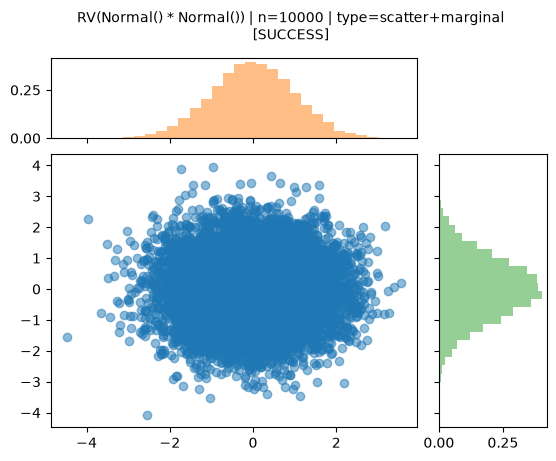

[SUCCESS] RV(Normal() * Normal()) | n=10000 | type=scatter+marginal


In [22]:
seed(151)
r = RV(Normal() * Normal()).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Normal() * Normal())', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='6. 2D continuous × continuous')

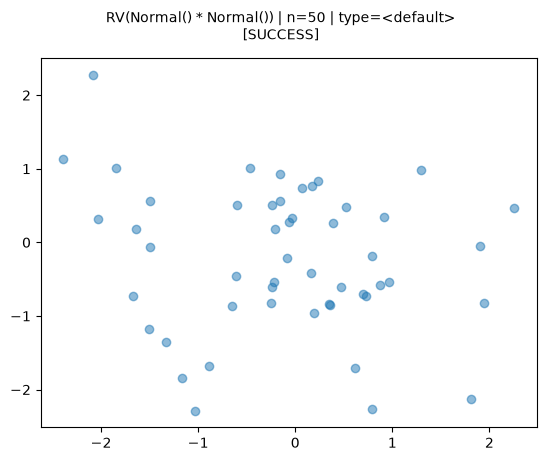

[SUCCESS] RV(Normal() * Normal()) | n=50 | type=<default>


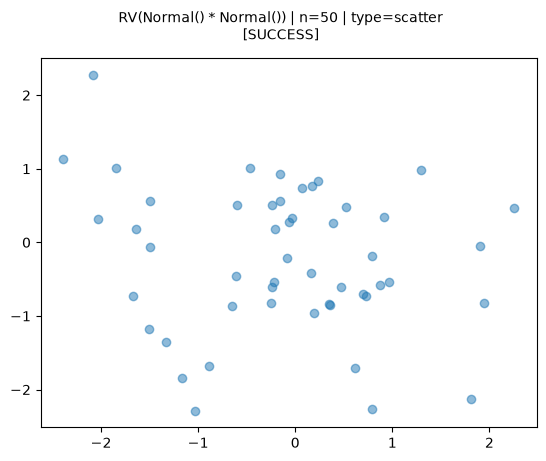

[SUCCESS] RV(Normal() * Normal()) | n=50 | type=scatter


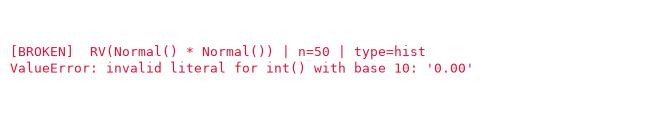

[BROKEN] RV(Normal() * Normal()) | n=50 | type=hist  ->  ValueError: invalid literal for int() with base 10: '0.00'


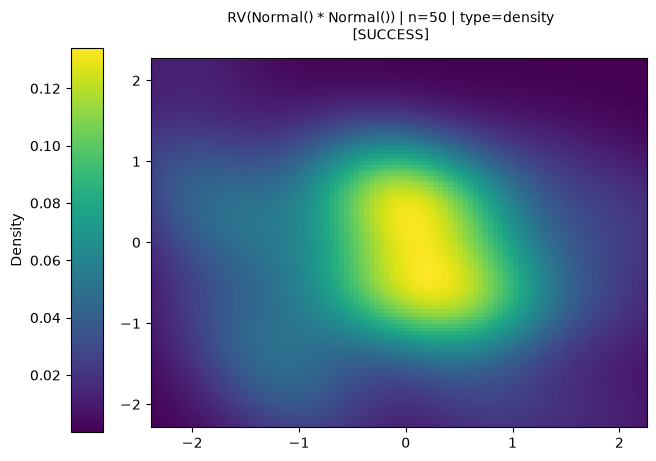

[SUCCESS] RV(Normal() * Normal()) | n=50 | type=density


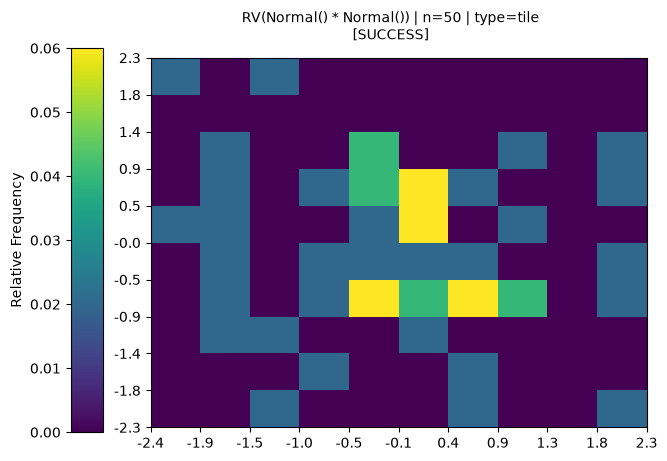

[SUCCESS] RV(Normal() * Normal()) | n=50 | type=tile


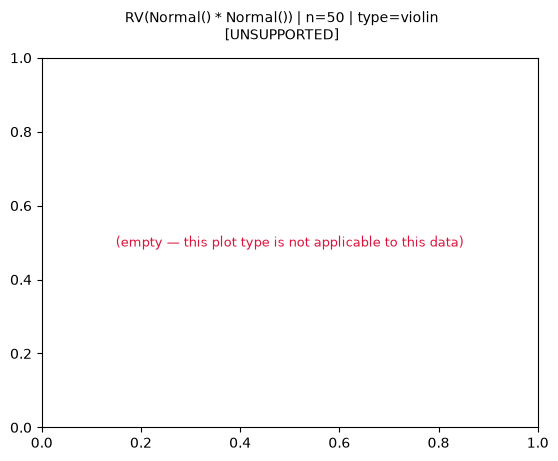

[UNSUPPORTED] RV(Normal() * Normal()) | n=50 | type=violin


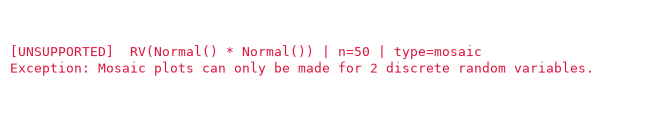

[UNSUPPORTED] RV(Normal() * Normal()) | n=50 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


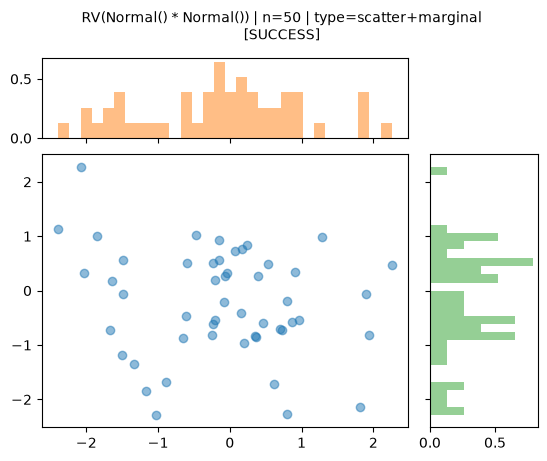

[SUCCESS] RV(Normal() * Normal()) | n=50 | type=scatter+marginal


In [23]:
seed(152)
r = RV(Normal() * Normal()).sim(50)          # built once, reused across all plot types
sweep(r, base='RV(Normal() * Normal())', n=50, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='6. 2D continuous × continuous')

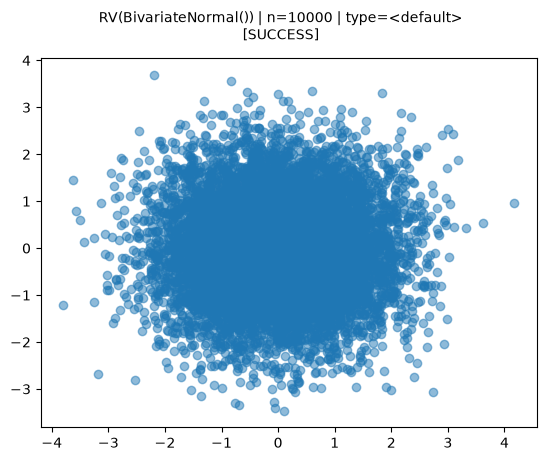

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=<default>


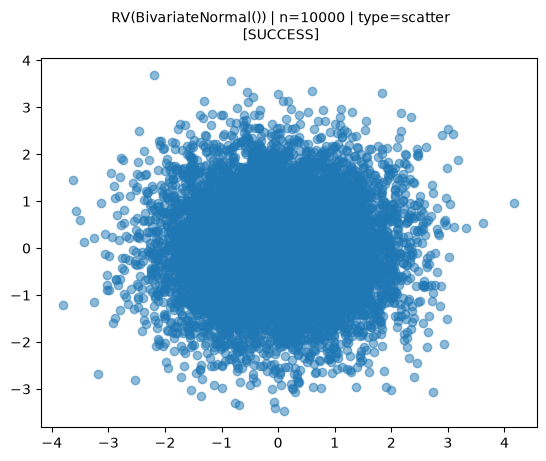

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=scatter


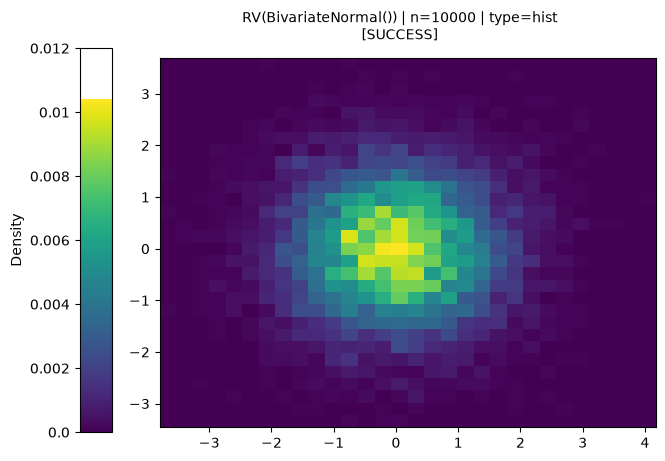

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=hist


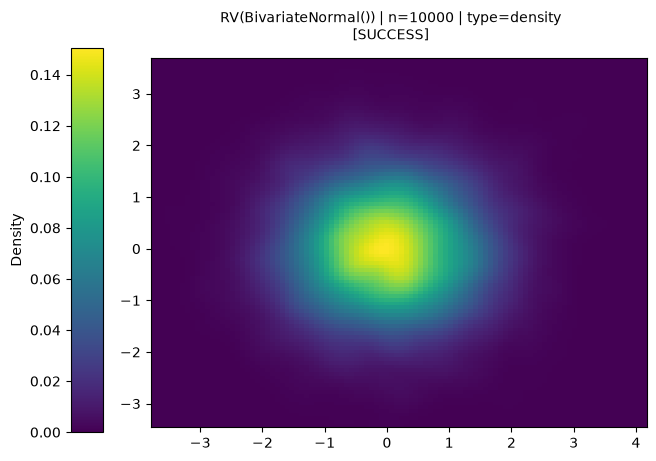

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=density


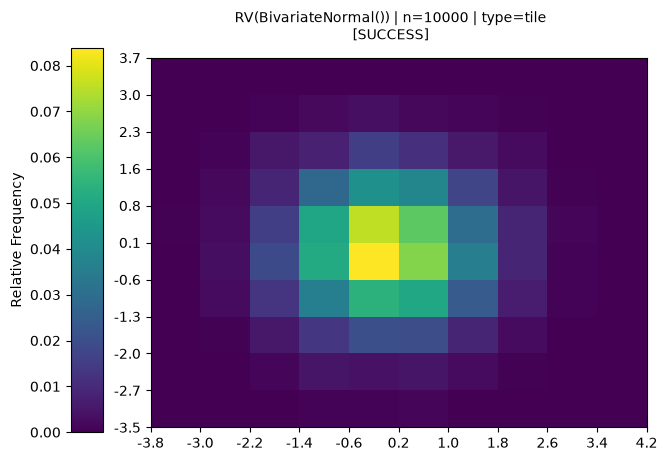

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=tile


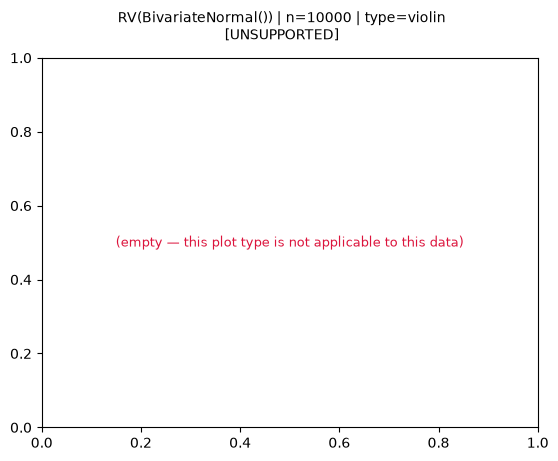

[UNSUPPORTED] RV(BivariateNormal()) | n=10000 | type=violin


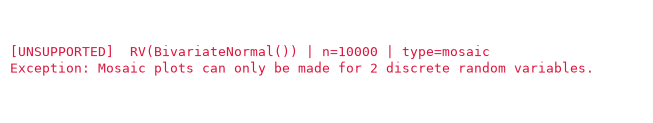

[UNSUPPORTED] RV(BivariateNormal()) | n=10000 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


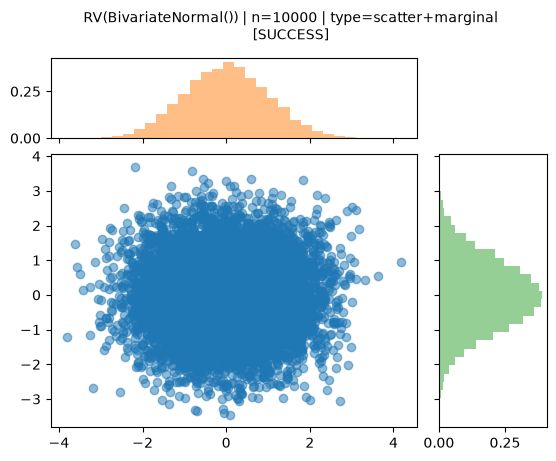

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=scatter+marginal


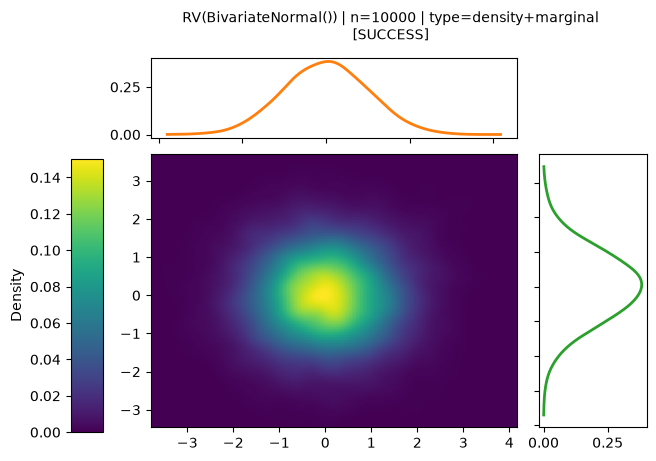

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=density+marginal


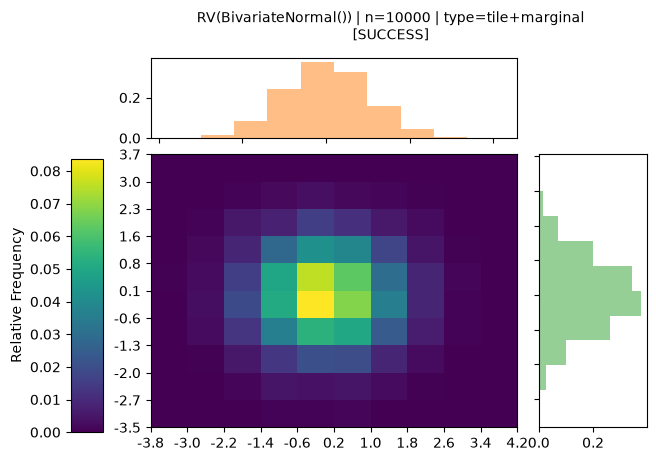

[SUCCESS] RV(BivariateNormal()) | n=10000 | type=tile+marginal


In [24]:
seed(153)
r = RV(BivariateNormal()).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(BivariateNormal())', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal'], ['density', 'marginal'], ['tile', 'marginal']], section='6. 2D continuous × continuous')

### Observations — 2D continuous × continuous

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Normal() * Normal()) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `violin` | &#11036; empty (n/a) |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Normal() * Normal()) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `hist` | &#10060; error (bug) |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `density` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `tile` | &#9989; yes |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `violin` | &#11036; empty (n/a) |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Normal() * Normal()) (n=50)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `violin` | &#11036; empty (n/a) |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `density+marginal` | &#9989; yes |  |  |  |
| `RV(BivariateNormal()) (n=10000)` | `tile+marginal` | &#9989; yes |  |  |  |

## 7. 2D discrete × continuous

x discrete, y continuous. This is the configuration where `violin` is meaningful. `mosaic` raises.

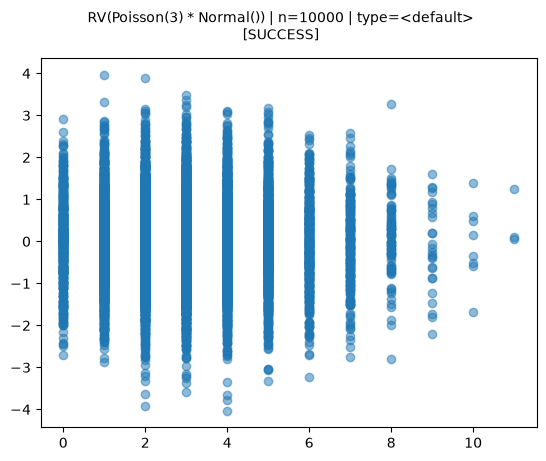

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=<default>


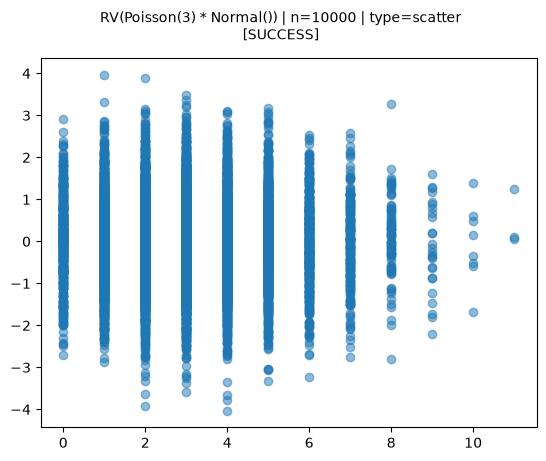

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=scatter


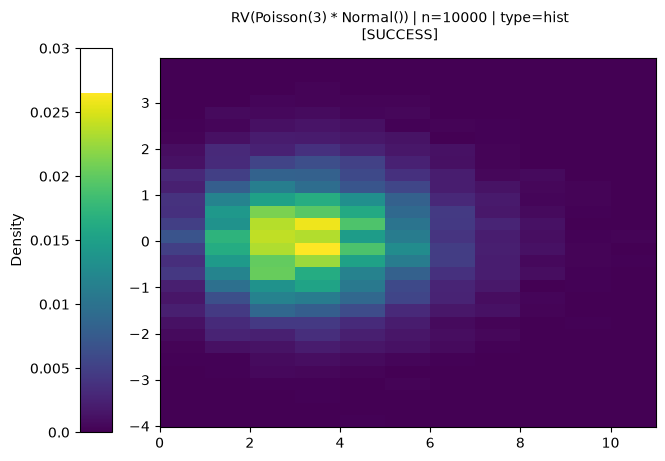

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=hist


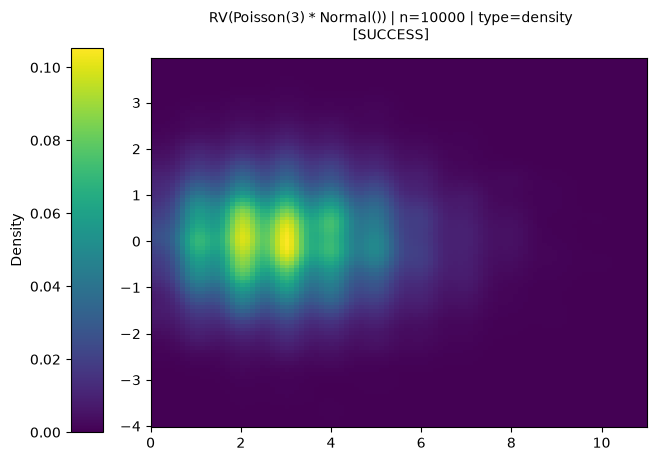

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=density


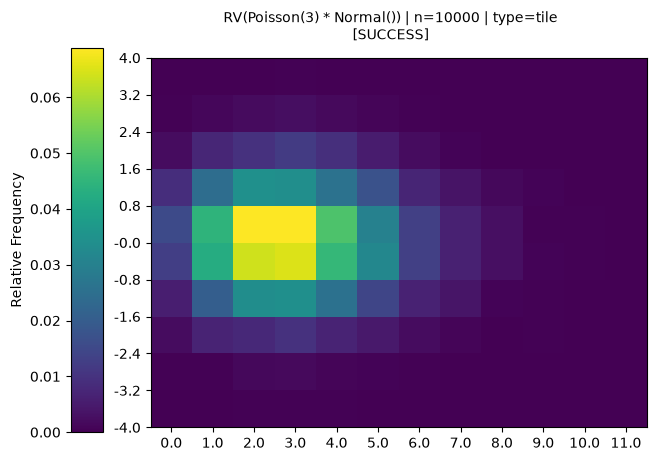

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=tile


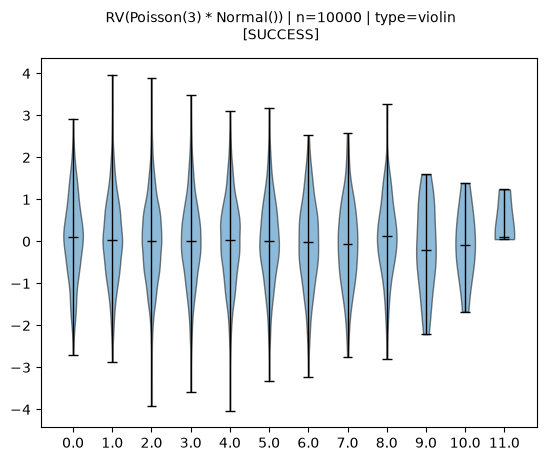

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=violin


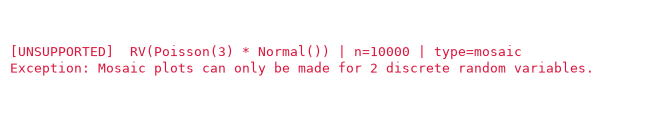

[UNSUPPORTED] RV(Poisson(3) * Normal()) | n=10000 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


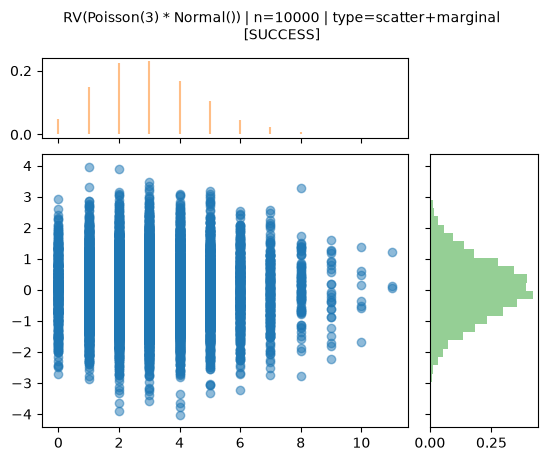

[SUCCESS] RV(Poisson(3) * Normal()) | n=10000 | type=scatter+marginal


In [25]:
seed(161)
r = RV(Poisson(3) * Normal()).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(3) * Normal())', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='7. 2D discrete × continuous')

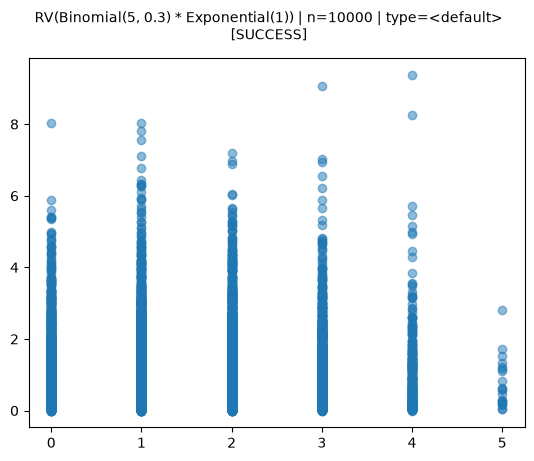

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=<default>


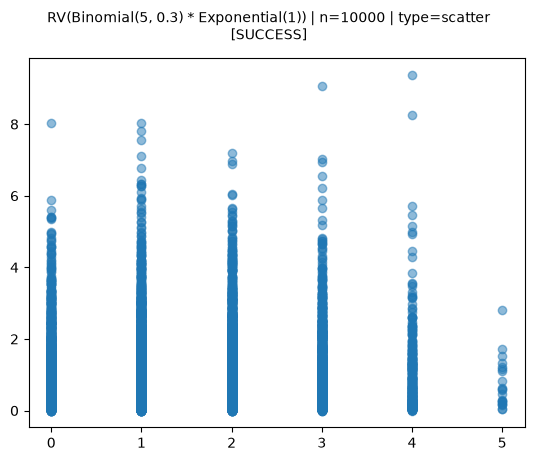

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=scatter


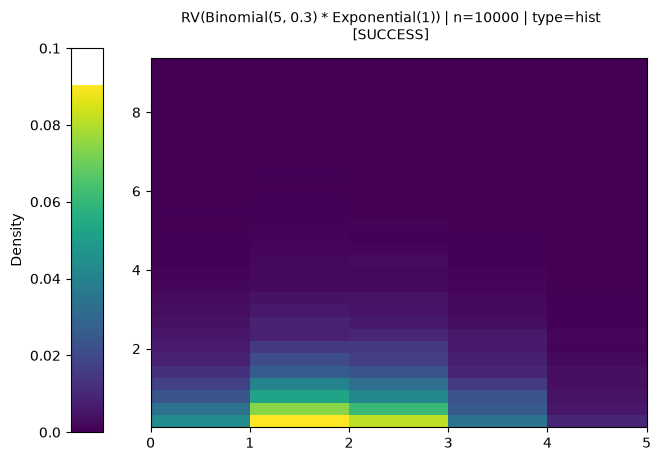

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=hist


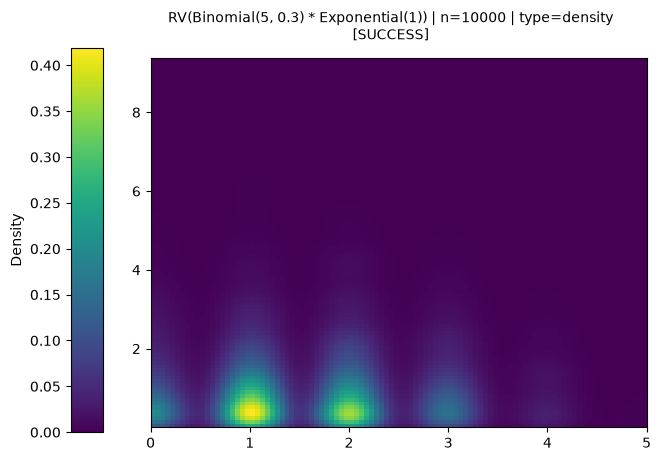

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=density


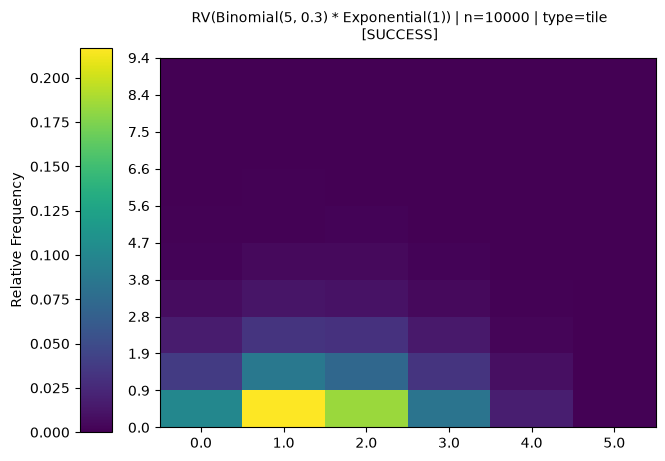

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=tile


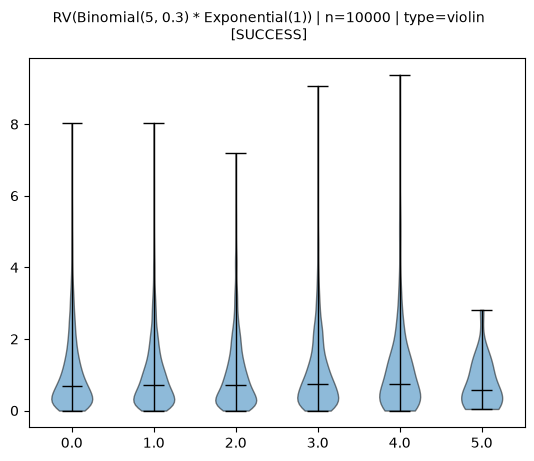

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=violin


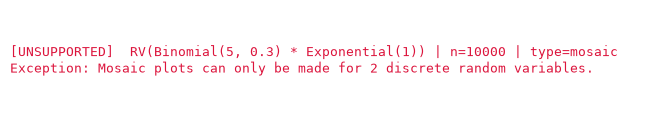

[UNSUPPORTED] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


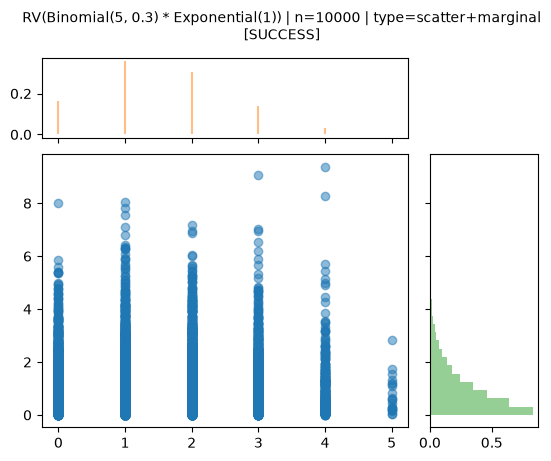

[SUCCESS] RV(Binomial(5, 0.3) * Exponential(1)) | n=10000 | type=scatter+marginal


In [26]:
seed(162)
r = RV(Binomial(5, 0.3) * Exponential(1)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Binomial(5, 0.3) * Exponential(1))', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='7. 2D discrete × continuous')

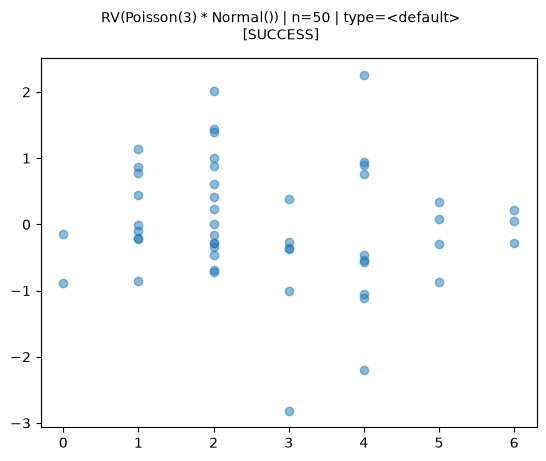

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=<default>


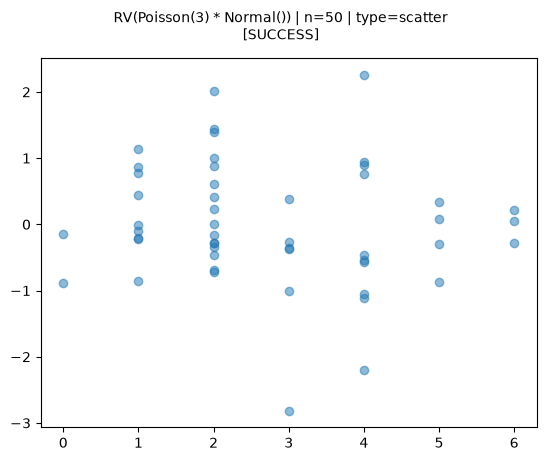

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=scatter


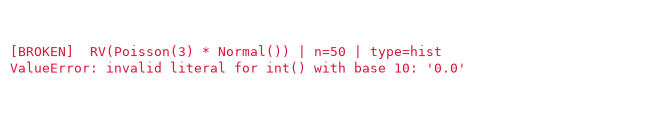

[BROKEN] RV(Poisson(3) * Normal()) | n=50 | type=hist  ->  ValueError: invalid literal for int() with base 10: '0.0'


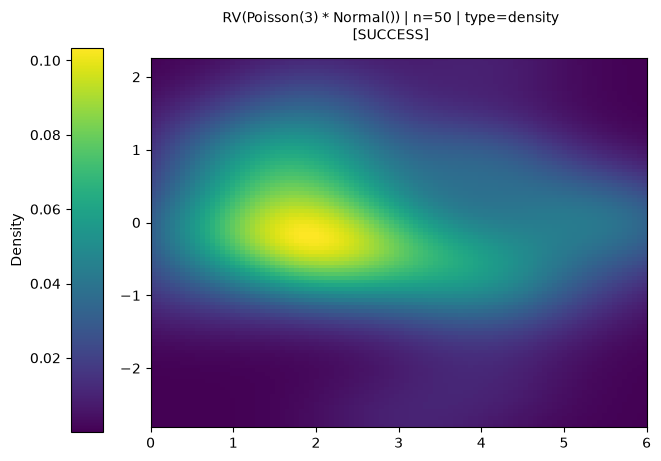

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=density


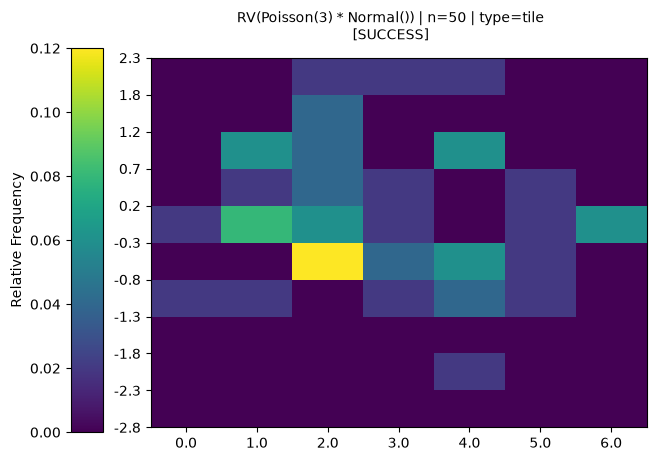

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=tile


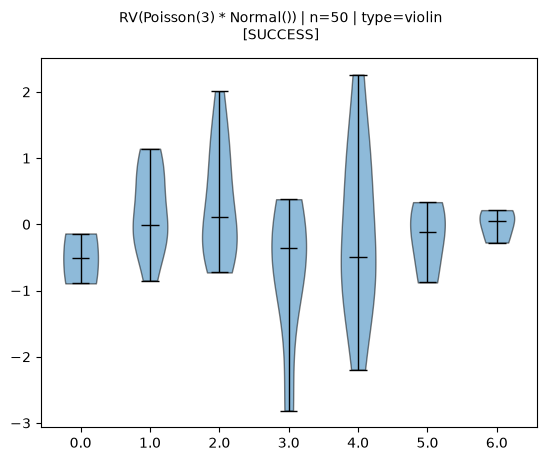

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=violin


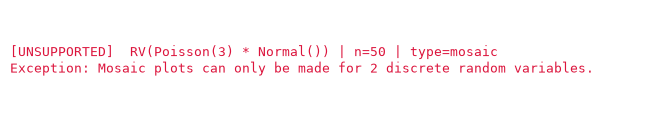

[UNSUPPORTED] RV(Poisson(3) * Normal()) | n=50 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


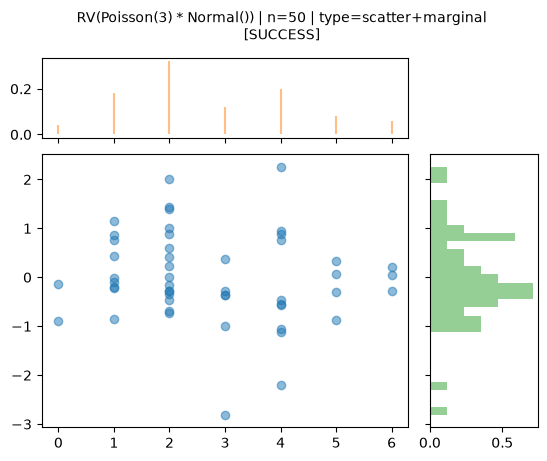

[SUCCESS] RV(Poisson(3) * Normal()) | n=50 | type=scatter+marginal


In [27]:
seed(163)
r = RV(Poisson(3) * Normal()).sim(50)          # built once, reused across all plot types
sweep(r, base='RV(Poisson(3) * Normal())', n=50, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='7. 2D discrete × continuous')

### Observations — 2D discrete × continuous

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Poisson(3) * Normal()) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `violin` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Poisson(3) * Normal()) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `violin` | &#9989; yes |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Binomial(5, 0.3) * Exponential(1)) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `hist` | &#10060; error (bug) |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `density` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `tile` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `violin` | &#9989; yes |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Poisson(3) * Normal()) (n=50)` | `scatter+marginal` | &#9989; yes |  |  |  |

## 8. 2D continuous × discrete

x continuous, y discrete — the mirror image of Section 7. `violin` should render across the (discrete) y-axis; `mosaic` raises.

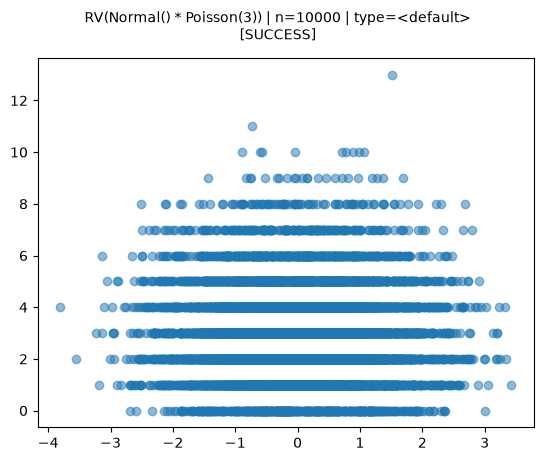

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=<default>


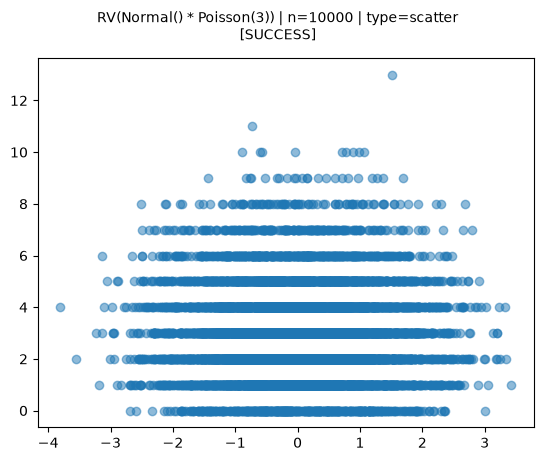

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=scatter


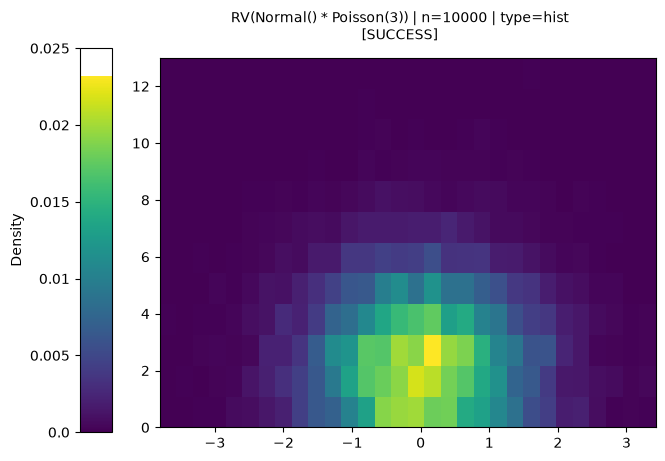

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=hist


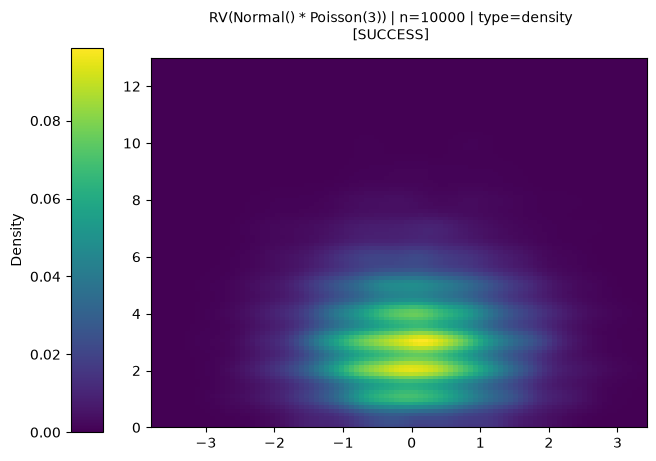

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=density


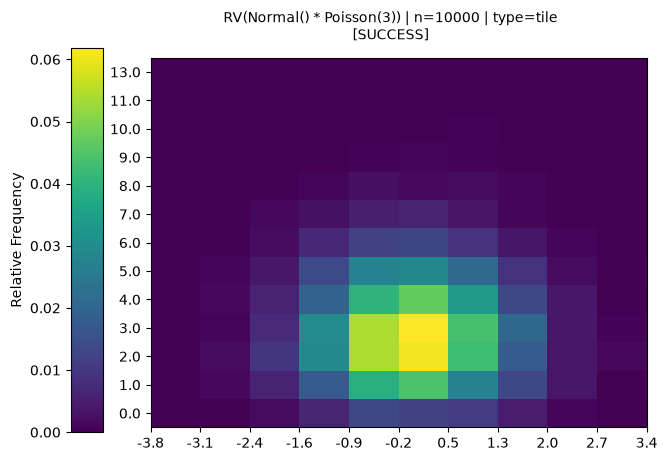

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=tile


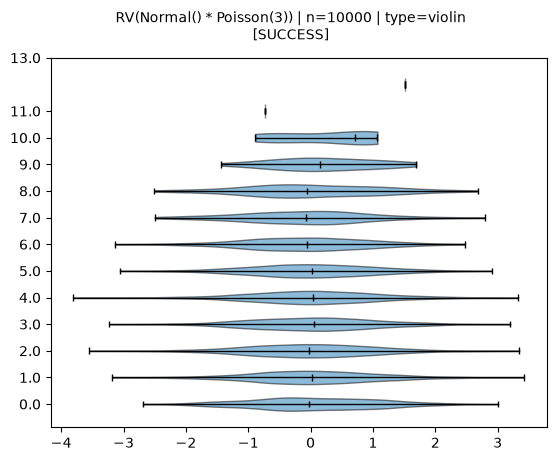

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=violin


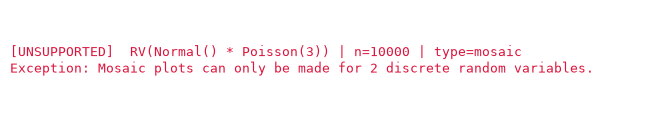

[UNSUPPORTED] RV(Normal() * Poisson(3)) | n=10000 | type=mosaic  ->  Exception: Mosaic plots can only be made for 2 discrete random variables.


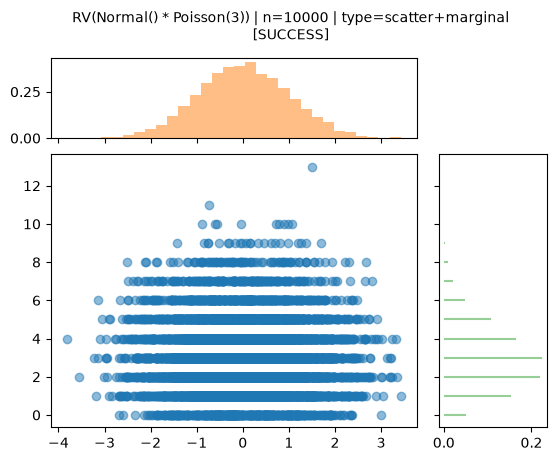

[SUCCESS] RV(Normal() * Poisson(3)) | n=10000 | type=scatter+marginal


In [28]:
seed(171)
r = RV(Normal() * Poisson(3)).sim(10000)          # built once, reused across all plot types
sweep(r, base='RV(Normal() * Poisson(3))', n=10000, types=[None, 'scatter', 'hist', 'density', 'tile', 'violin', 'mosaic', ['scatter', 'marginal']], section='8. 2D continuous × discrete')

### Observations — 2D continuous × discrete

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `RV(Normal() * Poisson(3)) (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `scatter` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `density` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `tile` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `violin` | &#9989; yes |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `mosaic` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(Normal() * Poisson(3)) (n=10000)` | `scatter+marginal` | &#9989; yes |  |  |  |

## 9. Process time point, discrete-valued

A stochastic process indexed at a fixed time, `X[t]`, yields a **1D** `RVResults` (dim=1) and flows through the ordinary 1D branch. `PoissonProcess(rate=5)[10]` is the **borderline** case (~50 support values).

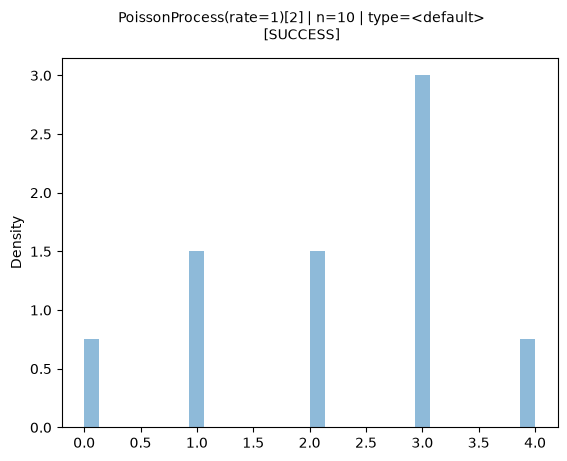

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=<default>


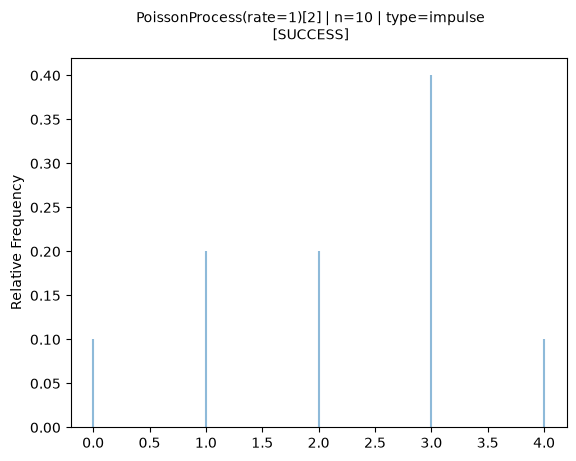

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=impulse


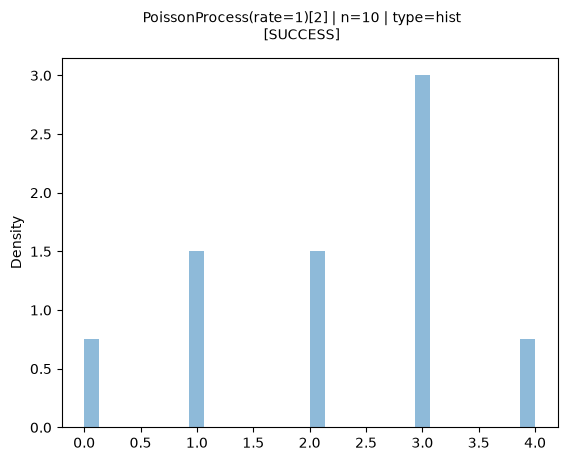

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=hist


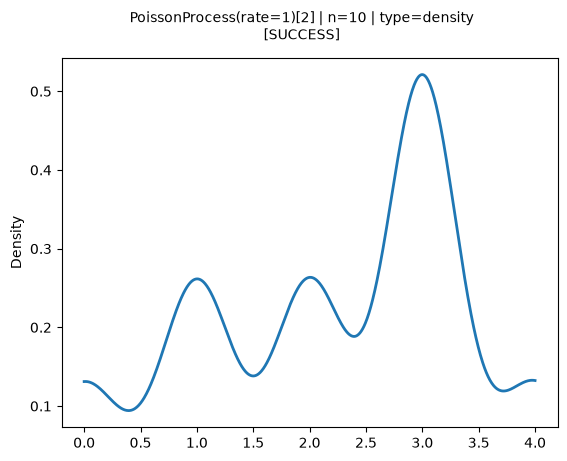

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=density


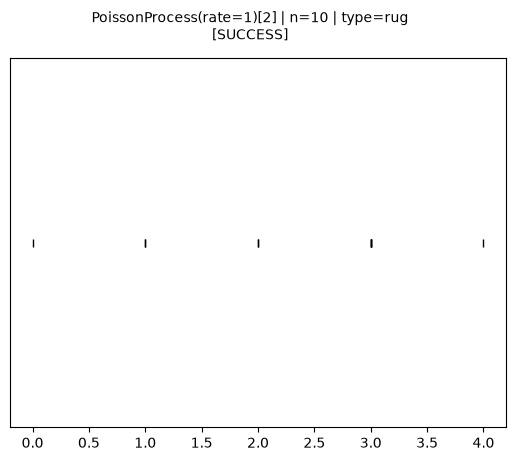

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=rug


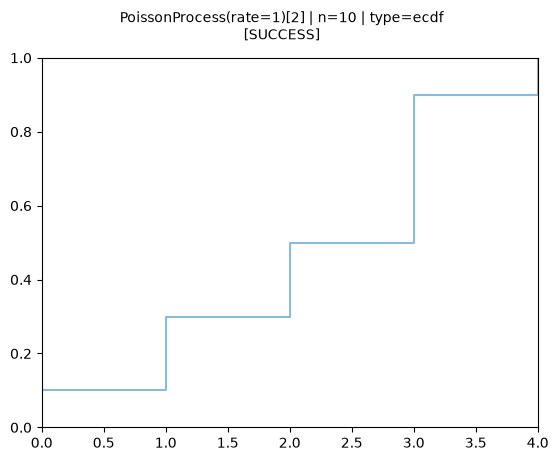

[SUCCESS] PoissonProcess(rate=1)[2] | n=10 | type=ecdf


In [29]:
seed(181)
r = PoissonProcess(rate=1)[2].sim(10)          # built once, reused across all plot types
sweep(r, base='PoissonProcess(rate=1)[2]', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='9. Process time point, discrete-valued')

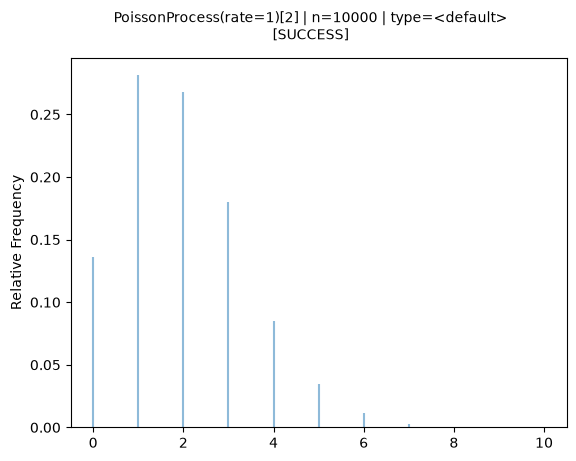

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=<default>


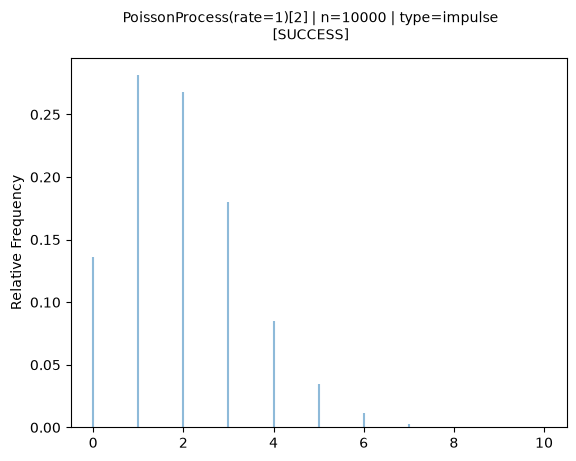

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=impulse


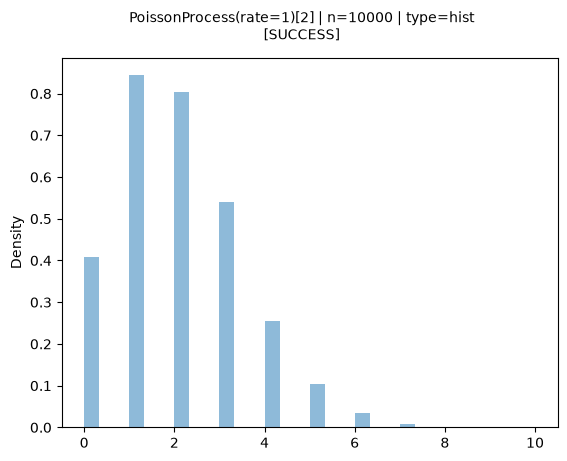

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=hist


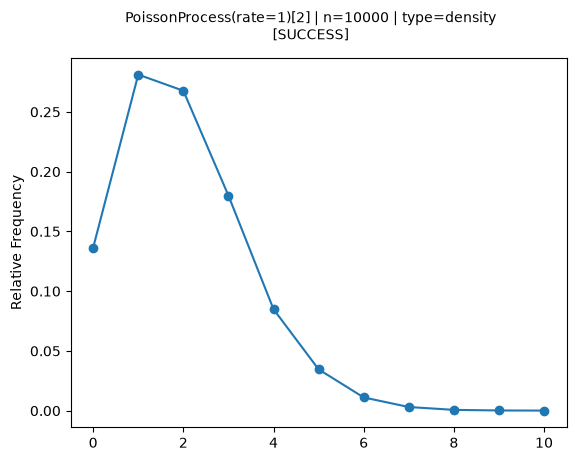

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=density


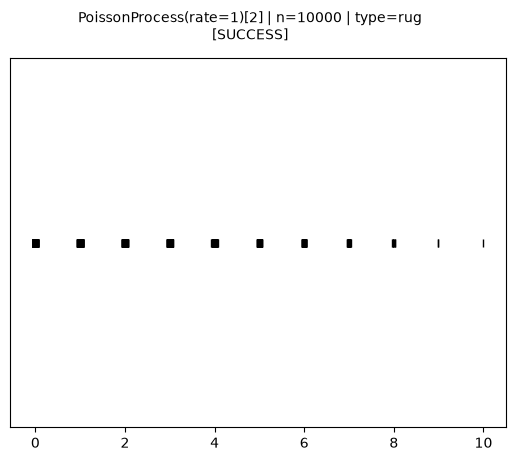

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=rug


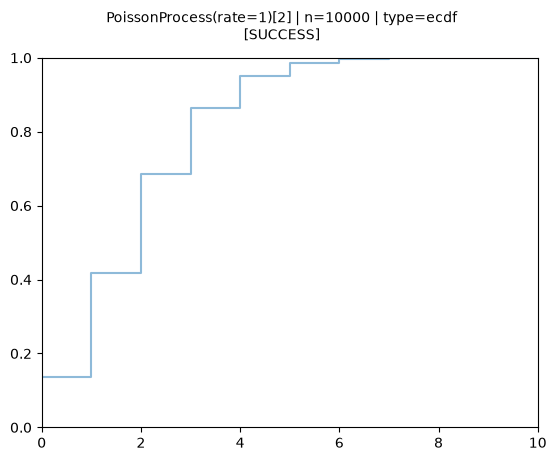

[SUCCESS] PoissonProcess(rate=1)[2] | n=10000 | type=ecdf


In [30]:
seed(182)
r = PoissonProcess(rate=1)[2].sim(10000)          # built once, reused across all plot types
sweep(r, base='PoissonProcess(rate=1)[2]', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='9. Process time point, discrete-valued')

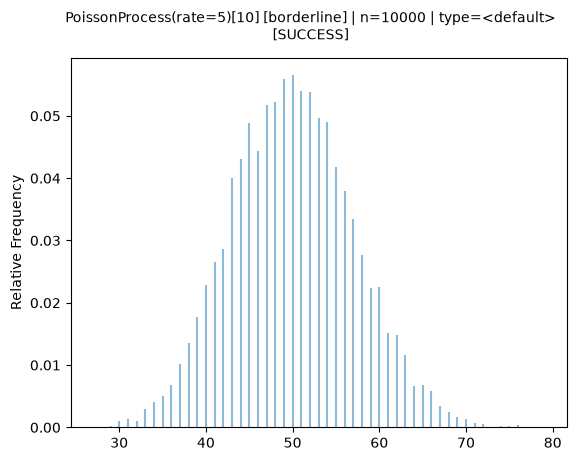

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=<default>


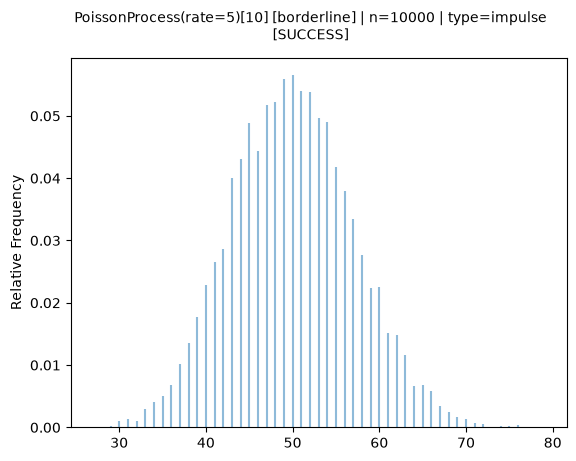

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=impulse


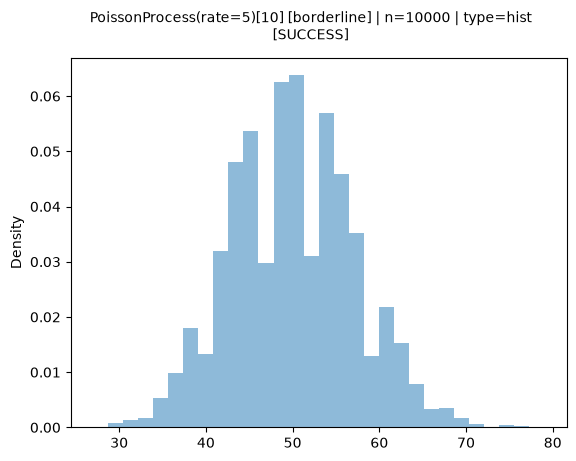

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=hist


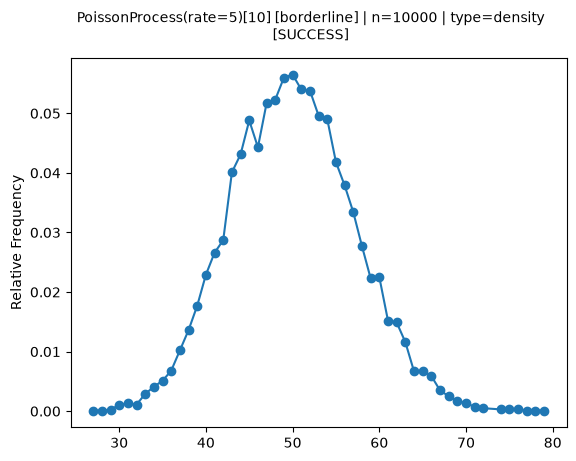

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=density


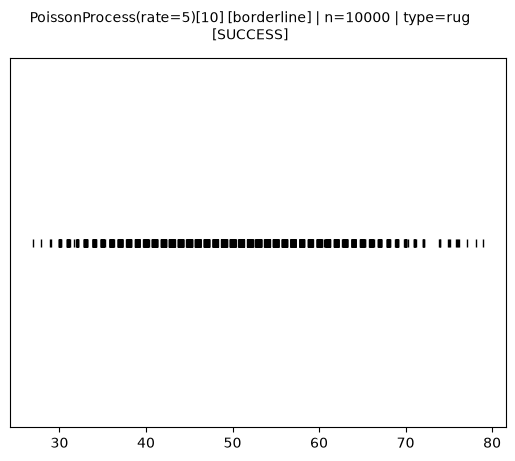

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=rug


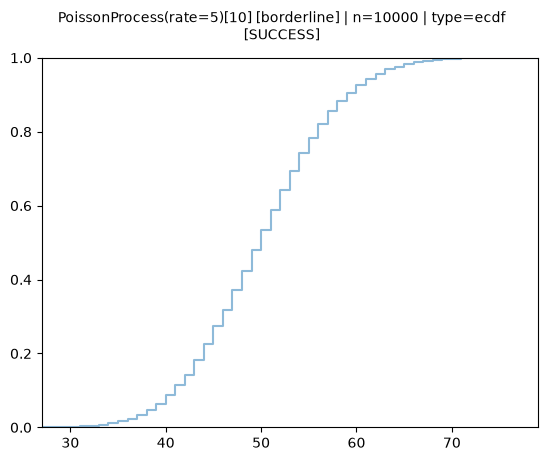

[SUCCESS] PoissonProcess(rate=5)[10] [borderline] | n=10000 | type=ecdf


In [31]:
seed(183)
r = PoissonProcess(rate=5)[10].sim(10000)          # built once, reused across all plot types
sweep(r, base='PoissonProcess(rate=5)[10] [borderline]', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='9. Process time point, discrete-valued')

### Observations — Process time point, discrete-valued

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `PoissonProcess(rate=1)[2] (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10)` | `hist` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10)` | `density` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10)` | `rug` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `density` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=1)[2] (n=10000)` | `ecdf` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `density` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `PoissonProcess(rate=5)[10] [borderline] (n=10000)` | `ecdf` | &#9989; yes |  |  |  |

## 10. Process time point, continuous-valued

`BrownianMotion()[1]` indexed at a fixed time yields continuous 1D values.

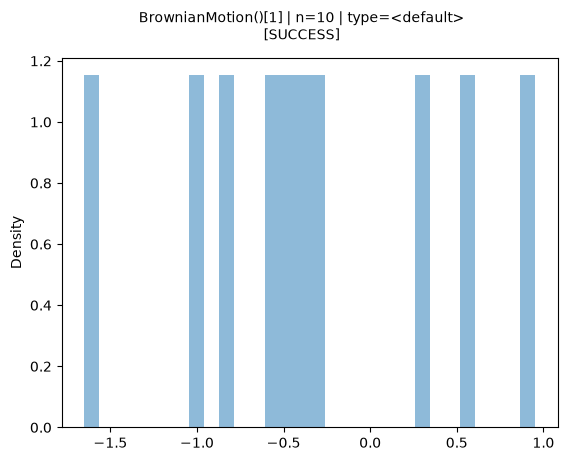

[SUCCESS] BrownianMotion()[1] | n=10 | type=<default>


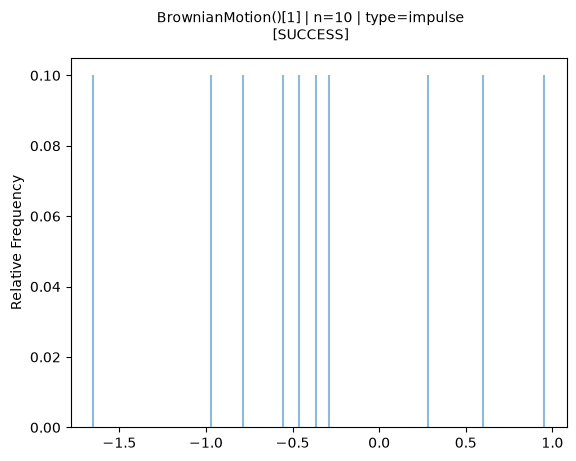

[SUCCESS] BrownianMotion()[1] | n=10 | type=impulse


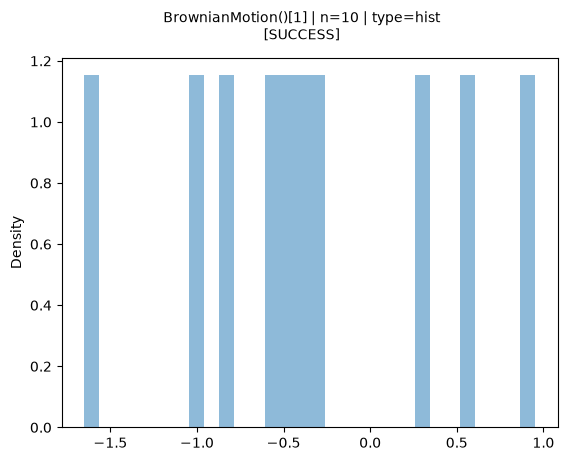

[SUCCESS] BrownianMotion()[1] | n=10 | type=hist


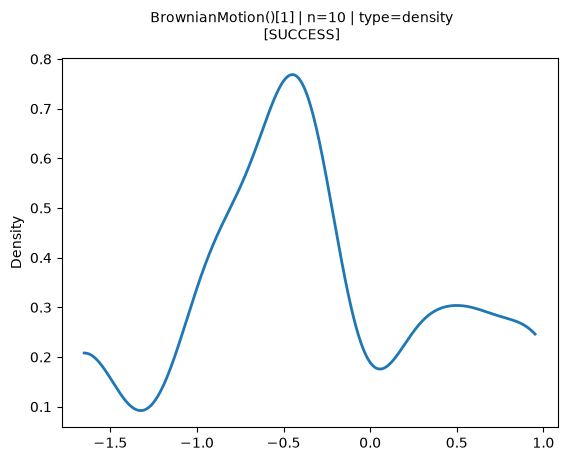

[SUCCESS] BrownianMotion()[1] | n=10 | type=density


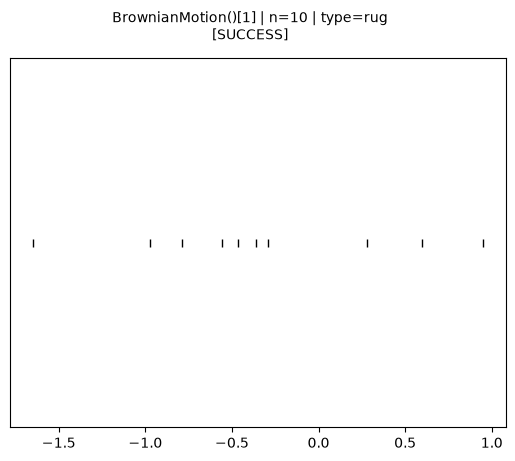

[SUCCESS] BrownianMotion()[1] | n=10 | type=rug


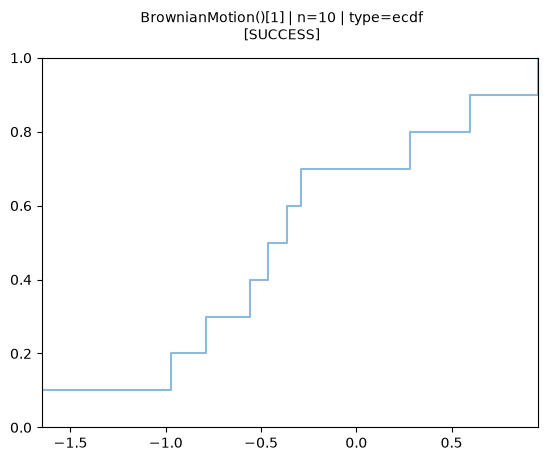

[SUCCESS] BrownianMotion()[1] | n=10 | type=ecdf


In [32]:
seed(191)
r = BrownianMotion()[1].sim(10)          # built once, reused across all plot types
sweep(r, base='BrownianMotion()[1]', n=10, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='10. Process time point, continuous-valued')

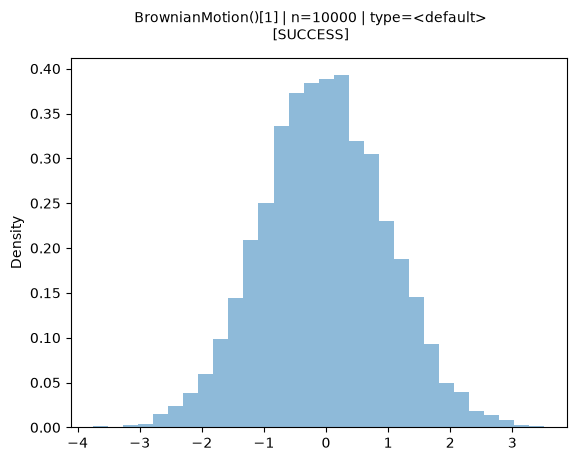

[SUCCESS] BrownianMotion()[1] | n=10000 | type=<default>


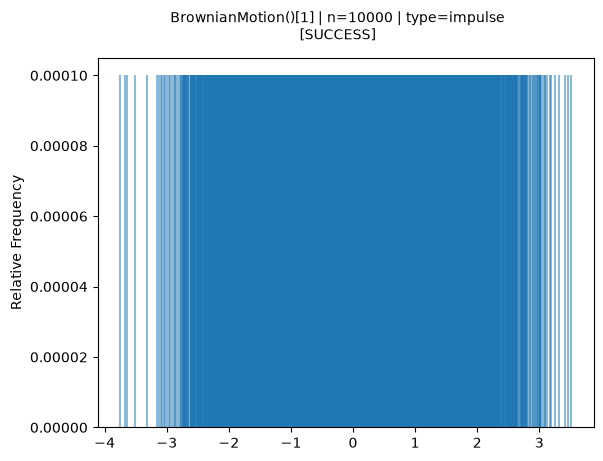

[SUCCESS] BrownianMotion()[1] | n=10000 | type=impulse


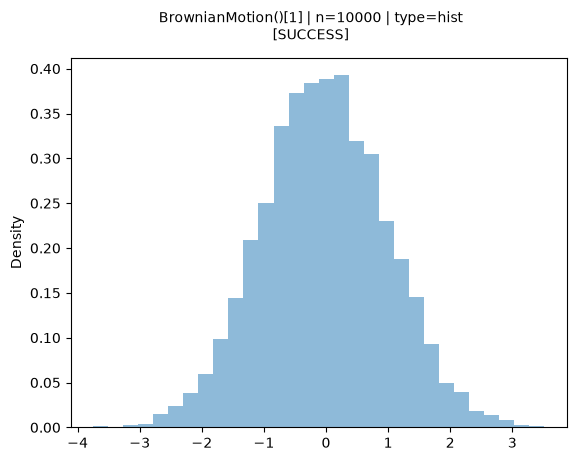

[SUCCESS] BrownianMotion()[1] | n=10000 | type=hist


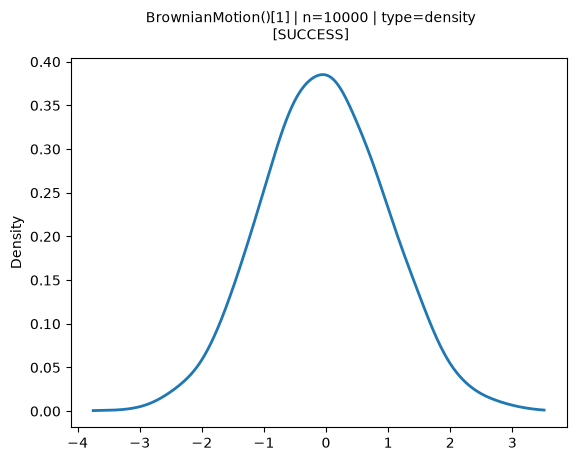

[SUCCESS] BrownianMotion()[1] | n=10000 | type=density


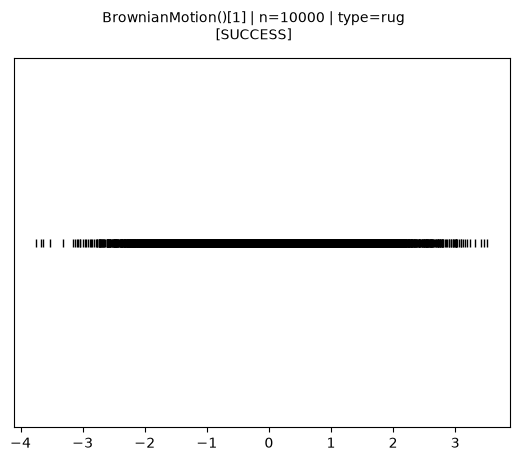

[SUCCESS] BrownianMotion()[1] | n=10000 | type=rug


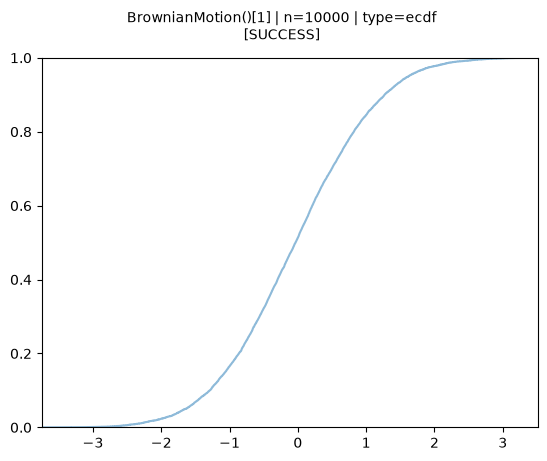

[SUCCESS] BrownianMotion()[1] | n=10000 | type=ecdf


In [33]:
seed(192)
r = BrownianMotion()[1].sim(10000)          # built once, reused across all plot types
sweep(r, base='BrownianMotion()[1]', n=10000, types=[None, 'impulse', 'hist', 'density', 'rug', 'ecdf'], section='10. Process time point, continuous-valued')

### Observations — Process time point, continuous-valued

*Rendered-status is filled automatically from the run; the last three columns are for you to complete after visually reviewing the plots above.*

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `BrownianMotion()[1] (n=10)` | `<default>` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10)` | `impulse` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10)` | `hist` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10)` | `density` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10)` | `rug` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10)` | `ecdf` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `<default>` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `impulse` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `hist` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `density` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `rug` | &#9989; yes |  |  |  |
| `BrownianMotion()[1] (n=10000)` | `ecdf` | &#9989; yes |  |  |  |

## 11. Categorical or string outcomes

String outcomes such as `BoxModel(['H', 'T'])` are the case the new `classify_data` is meant to route to a bar/impulse plot (object dtype → discrete-ish). **In the reference fork today they cannot be plotted at all:** the results have `dim=None`, so `.plot()` falls to the `else` branch and tries `.plot()` on each individual string outcome, raising `AttributeError`. Every plot type fails the same way. This is expected and is exactly the gap Task 1A/Phase 2 will close — do not treat it as a notebook bug.

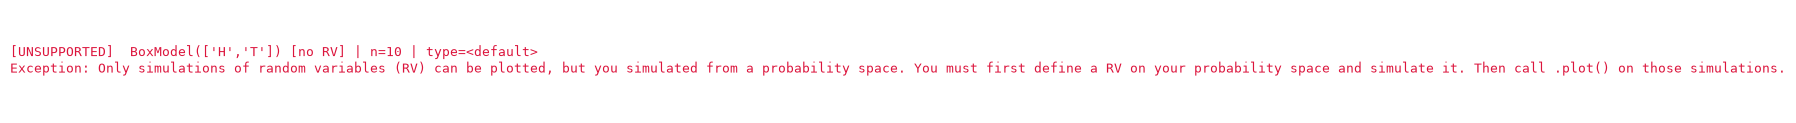

[UNSUPPORTED] BoxModel(['H','T']) [no RV] | n=10 | type=<default>  ->  Exception: Only simulations of random variables (RV) can be plotted, but you simulated from a probability space. You must first define a RV on your probability space and simulate it. Then call .plot() on those simulations.


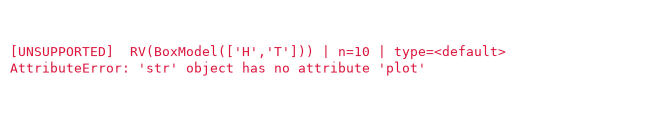

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10 | type=<default>  ->  AttributeError: 'str' object has no attribute 'plot'


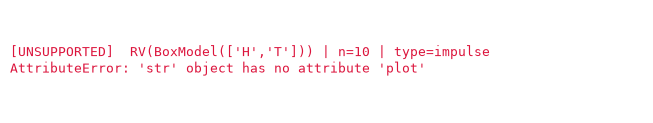

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10 | type=impulse  ->  AttributeError: 'str' object has no attribute 'plot'


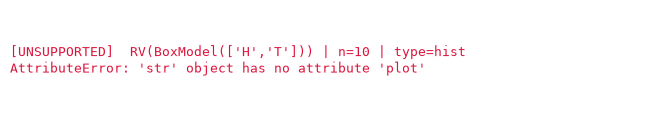

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10 | type=hist  ->  AttributeError: 'str' object has no attribute 'plot'


In [34]:
# Raw plan syntax (bare BoxModel, no RV): returns Results -> .plot() demands an RV.
seed(211)
raw_small = BoxModel(['H', 'T']).sim(10)
show('BoxModel([\'H\',\'T\']) [no RV]', 10, raw_small, None, '11. Categorical or string outcomes')

# RV-wrapped string outcomes, small n: every plot type hits the same dim=None AttributeError.
seed(212)
r_small = RV(BoxModel(['H', 'T'])).sim(10)
sweep(r_small, base="RV(BoxModel(['H','T']))", n=10, types=[None, 'impulse', 'hist'], section='11. Categorical or string outcomes')


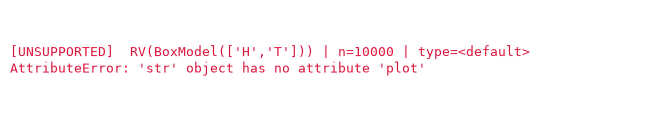

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10000 | type=<default>  ->  AttributeError: 'str' object has no attribute 'plot'


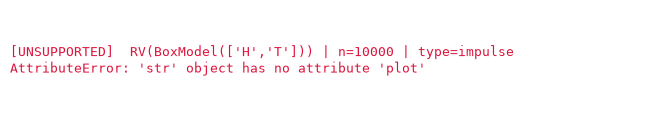

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10000 | type=impulse  ->  AttributeError: 'str' object has no attribute 'plot'


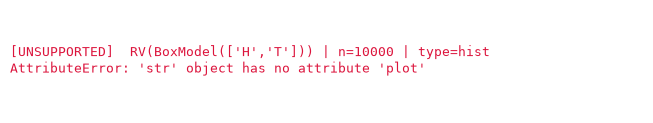

[UNSUPPORTED] RV(BoxModel(['H','T'])) | n=10000 | type=hist  ->  AttributeError: 'str' object has no attribute 'plot'


In [35]:
# RV-wrapped string outcomes, large n.
seed(213)
r_big = RV(BoxModel(['H', 'T'])).sim(10000)
sweep(r_big, base="RV(BoxModel(['H','T']))", n=10000, types=[None, 'impulse', 'hist'], section='11. Categorical or string outcomes')


### Observations — Categorical / string

| Example | Plot type | Rendered successfully? | Initial visual notes | Possible default? | Reasonable alternative? |
|---|---|---|---|---|---|
| `BoxModel(['H','T']) [no RV] (n=10)` | `<default>` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10)` | `<default>` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10)` | `impulse` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10)` | `hist` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10000)` | `<default>` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10000)` | `impulse` | &#9888;&#65039; unsupported (guarded error) |  |  |  |
| `RV(BoxModel(['H','T'])) (n=10000)` | `hist` | &#9888;&#65039; unsupported (guarded error) |  |  |  |

## 12. Overlay behavior

Each cell issues **two `.plot()` calls in one cell** (the only place this notebook does so). For every case the **expected** behavior (from the planning document) is printed alongside the **actual** behavior observed on the reference fork. Watch especially for the two cases where the reference fork *differs from the plan*: the two-tile overlay (plan expects a readability warning) and the marginal-then-second-plot overlay (plan expects a hard error).

**12.1 — Two continuous 1D plots** — plan: should overlay cleanly.

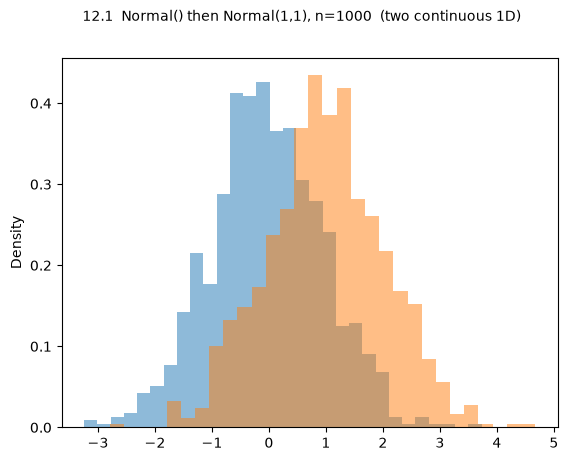

CASE    : 12.1  Normal() then Normal(1,1), n=1000  (two continuous 1D)
EXPECTED: Overlays cleanly on shared axes, second series in the next color.
ACTUAL  : rendered on shared axes, no warnings/errors


In [36]:
def _ov():
    seed(301); RV(Normal()).sim(1000).plot()
    seed(302); RV(Normal(1, 1)).sim(1000).plot()
overlay('12.1  Normal() then Normal(1,1), n=1000  (two continuous 1D)', _ov,
        'Overlays cleanly on shared axes, second series in the next color.')


**12.2 — Two discrete 1D plots** — plan: should overlay cleanly.

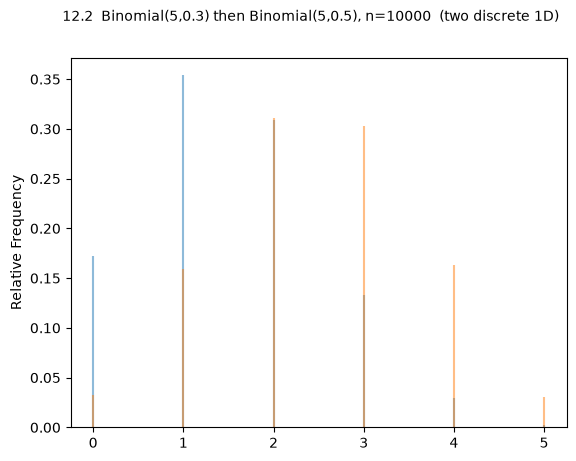

CASE    : 12.2  Binomial(5,0.3) then Binomial(5,0.5), n=10000  (two discrete 1D)
EXPECTED: Overlays cleanly on shared axes (two sets of impulses, distinct colors).
ACTUAL  : rendered on shared axes, no warnings/errors


In [37]:
def _ov():
    seed(303); RV(Binomial(5, 0.3)).sim(10000).plot()
    seed(304); RV(Binomial(5, 0.5)).sim(10000).plot()
overlay('12.2  Binomial(5,0.3) then Binomial(5,0.5), n=10000  (two discrete 1D)', _ov,
        'Overlays cleanly on shared axes (two sets of impulses, distinct colors).')


**12.3 — Two 2D scatter plots** — plan: should overlay cleanly.

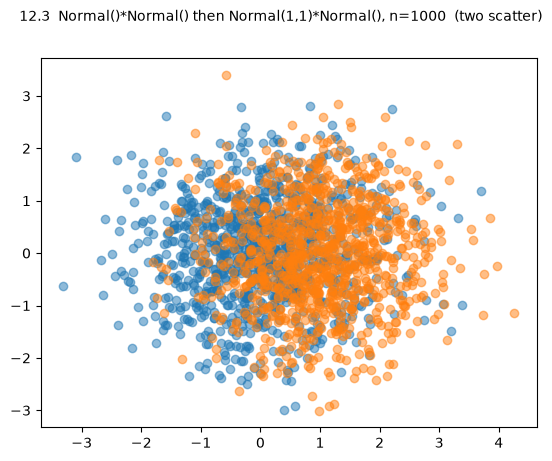

CASE    : 12.3  Normal()*Normal() then Normal(1,1)*Normal(), n=1000  (two scatter)
EXPECTED: Overlays cleanly on shared axes, second cloud in the next color.
ACTUAL  : rendered on shared axes, no warnings/errors


In [38]:
def _ov():
    seed(305); RV(Normal() * Normal()).sim(1000).plot('scatter')
    seed(306); RV(Normal(1, 1) * Normal()).sim(1000).plot('scatter')
overlay('12.3  Normal()*Normal() then Normal(1,1)*Normal(), n=1000  (two scatter)', _ov,
        'Overlays cleanly on shared axes, second cloud in the next color.')


**12.4 — Two 2D tile plots** — plan: overlay attempted, **readability warning expected** (competing color scales). Observe whether the reference fork actually emits a warning.

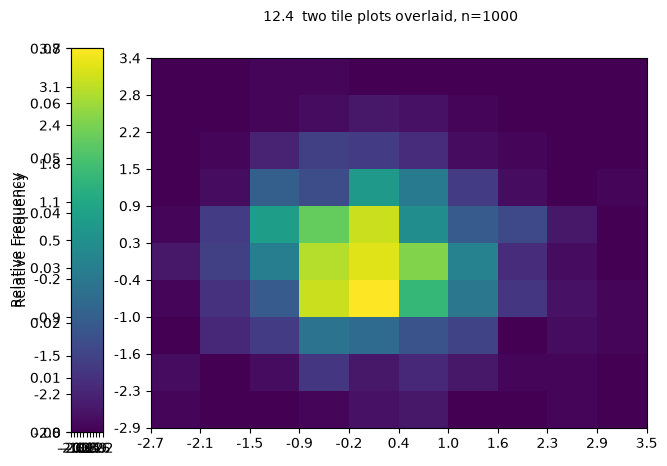

CASE    : 12.4  two tile plots overlaid, n=1000
EXPECTED: Plan: overlay produced BUT a readability warning is printed (competing color scales).
ACTUAL  : rendered on shared axes, no warnings/errors


In [39]:
def _ov():
    seed(307); RV(Normal() * Normal()).sim(1000).plot('tile')
    seed(308); RV(Normal(1, 1) * Normal()).sim(1000).plot('tile')
overlay('12.4  two tile plots overlaid, n=1000', _ov,
        'Plan: overlay produced BUT a readability warning is printed (competing color scales).')


**12.5 — Marginal layout then a second plot** — plan: **hard error expected** (a second `.plot()` cannot join a `GridSpec` marginal layout). Observe whether the reference fork actually errors.

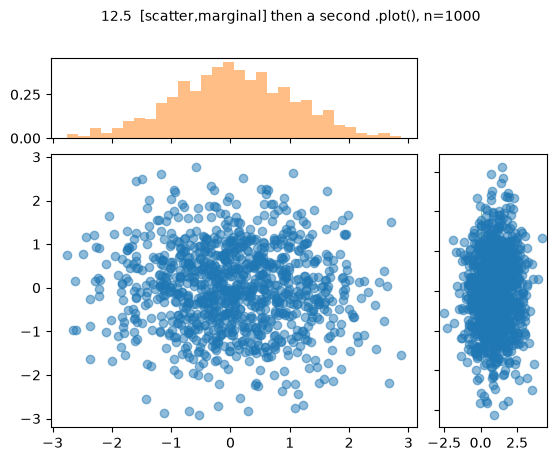

CASE    : 12.5  [scatter,marginal] then a second .plot(), n=1000
EXPECTED: Plan: hard error (cannot overlay onto a marginal GridSpec layout).
ACTUAL  : rendered on shared axes, no warnings/errors


In [40]:
def _ov():
    seed(309); RV(Normal() * Normal()).sim(1000).plot(['scatter', 'marginal'])
    seed(310); RV(Normal(1, 1) * Normal()).sim(1000).plot()
overlay('12.5  [scatter,marginal] then a second .plot(), n=1000', _ov,
        'Plan: hard error (cannot overlay onto a marginal GridSpec layout).')


**12.6 — Categorical `BoxModel(['H','T'])`, small and large n.** The planning document lists these under the overlay tests, but each is a single `.plot()` call (not an overlay). They are the same string-outcome case as Section 11 and are expected to raise. Shown here for completeness against the plan's list.

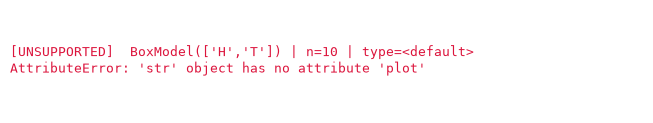

[UNSUPPORTED] BoxModel(['H','T']) | n=10 | type=<default>  ->  AttributeError: 'str' object has no attribute 'plot'


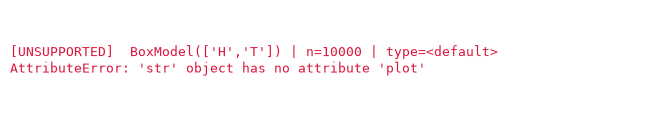

[UNSUPPORTED] BoxModel(['H','T']) | n=10000 | type=<default>  ->  AttributeError: 'str' object has no attribute 'plot'


In [41]:
seed(311)
show("BoxModel(['H','T'])", 10, RV(BoxModel(['H', 'T'])).sim(10), None, '12. Overlay behavior')
seed(312)
show("BoxModel(['H','T'])", 10000, RV(BoxModel(['H', 'T'])).sim(10000), None, '12. Overlay behavior')


### Observations — Overlay behavior

*Record the actual behavior you see for each case; note whether it overlays cleanly, has a readability problem, raises an error, or differs from the plan.*

| Case | Expected (plan) | Actual (reference fork) | Overlay clean / warning / error / differs? | Notes |
|---|---|---|---|---|
| 12.1 two continuous 1D | clean overlay |  |  |  |
| 12.2 two discrete 1D | clean overlay |  |  |  |
| 12.3 two scatter | clean overlay |  |  |  |
| 12.4 two tile | readability **warning** |  |  |  |
| 12.5 marginal then plot | **hard error** |  |  |  |
| 12.6 categorical H/T | (single plot) |  |  |  |

## Draft Phase 1 lookup table (to be filled in by the team)

This is intentionally **blank** — the notebook's job is to provide the visual evidence, not to make the design decisions. Fill each cell with one default plot type and a short list of reasonable alternatives after reviewing the plots above.

| Data configuration | Small n default | Small n alternatives | Large n default | Large n alternatives |
|---|---|---|---|---|
| 1D discrete-ish |  |  |  |  |
| 1D continuous-ish |  |  |  |  |
| 2D discrete × discrete |  |  |  |  |
| 2D continuous × continuous |  |  |  |  |
| 2D discrete × continuous |  |  |  |  |
| 2D continuous × discrete |  |  |  |  |
| Process time point, discrete-valued |  |  |  |  |
| Process time point, continuous-valued |  |  |  |  |
| 1D categorical/string |  |  |  |  |

**Scope reminder (explicitly out of scope for this notebook):** do not implement `classify_data`, do not fill in the final lookup table in code, and do not begin Phase 2 or later. This deliverable is Step 1 of Task 1A only.

### Machine-readable run log

The cell below prints every recorded outcome as JSON (also used to auto-fill the *Rendered successfully?* columns above) and a short summary of everything that failed.

In [42]:
import json
print('RESULTS_LOG_JSON_BEGIN')
print(json.dumps(RESULTS_LOG))
print('RESULTS_LOG_JSON_END')

fails = [r for r in RESULTS_LOG if r['status'] in ('ERROR', 'EMPTY')]
print()
print('Total plot attempts :', len(RESULTS_LOG))
print('SUCCESS             :', sum(1 for r in RESULTS_LOG if r['status'] == 'SUCCESS'))
print('EMPTY (n/a)         :', sum(1 for r in RESULTS_LOG if r['status'] == 'EMPTY'))
print('ERROR               :', sum(1 for r in RESULTS_LOG if r['status'] == 'ERROR'))
print()
print('Non-SUCCESS attempts:')
for r in fails:
    print('  [%s/%s] %s | %s | %s' % (r['status'], r['label'], r['section'], r['plot_type'], r['error'] or '(empty plot)'))


RESULTS_LOG_JSON_BEGIN
[{"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10)", "plot_type": "<default>", "status": "SUCCESS", "label": "SUCCESS", "error": "", "warnings": []}, {"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10)", "plot_type": "impulse", "status": "SUCCESS", "label": "SUCCESS", "error": "", "warnings": []}, {"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10)", "plot_type": "hist", "status": "SUCCESS", "label": "SUCCESS", "error": "", "warnings": []}, {"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10)", "plot_type": "density", "status": "SUCCESS", "label": "SUCCESS", "error": "", "warnings": []}, {"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10)", "plot_type": "rug", "status": "SUCCESS", "label": "SUCCESS", "error": "", "warnings": []}, {"section": "1. 1D discrete-ish, small n", "example": "RV(Binomial(5, 0.3)) (n=10